# Thai Fisheries Trade — ML Project (CRISP-DM)

**โปรเจกต์วิชา Machine Learning** · วิเคราะห์การส่งออกสินค้าประมงของไทยด้วย Open Data ตามกระบวนการ CRISP-DM

| ขั้นตอน | สถานะใน notebook นี้ |
|---|---|
| 1. Business Understanding | ✅ ส่วนที่ 1 |
| 2. Data Understanding | ✅ ส่วนที่ 2 |
| 3. Data Preparation · 4. Modeling · 5. Evaluation · 6. Deployment | ⏳ ยังไม่ทำ (เพิ่มต่อใน notebook นี้) |

> **วิธีรัน:** เปิดจากโฟลเดอร์โปรเจกต์ (หรือโฟลเดอร์ที่มี `DATASET/`) ใช้ Python 3.10+ และ `pip install pandas numpy matplotlib` ผลลัพธ์ทุกตัวเลขในเอกสารนี้ถูกคำนวณจากไฟล์ใน `DATASET/` จริง ไม่ได้พิมพ์ตัวเลขเอง
> รายละเอียดทุกไฟล์ (คอลัมน์ หน่วย ที่มา ปัญหาที่พบ) อยู่ที่ [`DATASET/DICTIONARY.md`](DATASET/DICTIONARY.md)

---
# 1. Business Understanding

## 1.1 บริบทและที่มาของปัญหา

สินค้าประมง (กุ้ง ปลา ปลาแช่แข็ง ปลากระป๋อง หมึก ฯลฯ) เป็นกลุ่มสินค้าส่งออกที่ไทยขายให้ตลาดต่างประเทศจำนวนมาก ผู้ส่งออกและผู้กำหนดนโยบายต้องตัดสินใจโดยอาศัยภาพของ **"ตลาดไหนสำคัญ ตลาดไหนกำลังเปลี่ยนไป"** แต่ข้อมูลที่เปิดเผยต่อสาธารณะเป็นตารางตัวเลขรายเดือน จำนวนหลายหมื่นแถวต่อปี (ประเทศ × รหัสสินค้า × เดือน) ซึ่งอ่านด้วยตาไม่ได้ จุดที่ machine learning ช่วยได้คือ **พยากรณ์ยอดล่วงหน้า** **สรุปโครงสร้างของตลาด** และ **เตือนล่วงหน้า** เมื่อสัญญาณของตลาดใดเริ่มผิดปกติ — โดยต้องตอบด้วยว่า *ตัวเลขเหล่านี้เชื่อถือได้แค่ไหน*

> ตัวเลขขนาดตลาดและความกระจุกตัวที่ใช้ยืนยันบริบทนี้ คำนวณจากข้อมูลจริงในส่วน 2.2 (Data Understanding)

## 1.2 ผู้มีส่วนได้ส่วนเสียและประโยชน์ที่ได้

| ผู้ใช้ผลลัพธ์ | ต้องการรู้อะไร | ใช้ผลลัพธ์ทำอะไร |
|---|---|---|
| ผู้ส่งออก / โรงงานแปรรูปอาหารทะเล | ตลาดที่พึ่งพาอยู่เป็นแบบไหน ตลาดไหนเริ่มอ่อนแรง | กระจายความเสี่ยงไปตลาดอื่น วางแผนกำลังผลิตและสต็อก |
| กรมประมง | ภาพรวมโครงสร้างตลาดและความเสี่ยง | กำกับดูแลและวางแผนสนับสนุนเกษตรกร/ผู้ประกอบการ |
| กรมส่งเสริมการค้าระหว่างประเทศ | ตลาดใดควรเข้าไปส่งเสริม ตลาดใดต้องเร่งแก้ไข | จัดกิจกรรมส่งเสริมการขาย/เจรจาการค้าให้ตรงกลุ่ม |
| ทีมโปรเจกต์ (นักศึกษา) | ผลงานที่ทำซ้ำได้ ตรวจสอบได้ และสะท้อนข้อจำกัดของข้อมูลอย่างตรงไปตรงมา | ส่งรายงานและนำเสนอ |

## 1.3 เป้าหมายทางธุรกิจ (Business Objectives)

1. **พยากรณ์ยอดส่งออกล่วงหน้าเป็นรายเดือน (หลัก)** — ให้ผู้ส่งออกและหน่วยงานเห็นแนวโน้มยอดของแต่ละตลาด/กลุ่มสินค้าล่วงหน้า เพื่อวางแผนการผลิต สต็อก และกิจกรรมส่งเสริมตลาด *และบอกให้ชัดว่าตัวเลขพยากรณ์เชื่อถือได้แค่ไหนในแต่ละระดับ* (ตลาดเล็ก/ใหญ่ ระยะสั้น/ยาว)
2. **เข้าใจโครงสร้างตลาดส่งออก (ส่วนที่ต้องส่งมอบ)** — จัดกลุ่มตลาดตามพฤติกรรม เพื่ออธิบายว่าโมเดลพยากรณ์ได้แม่นในตลาดกลุ่มไหน และกำหนดกลยุทธ์แยกกลุ่ม
3. **เตือนภัยล่วงหน้า (เสริม ถ้ามีเวลา)** — ระบุตลาดที่มีแนวโน้มยอดตกแรง

## 1.4 เป้าหมายทาง Data Mining (Data Mining Goals)

> **การตัดสินใจเรื่องโจทย์หลัก:** ทีมเลือก **การพยากรณ์ยอดส่งออกรายเดือน** เป็นโจทย์หลักตามแผนเดิมใน README ผลสำรวจข้อมูลในส่วนที่ 2 (ส่วน 2.2.1) ชี้ว่าข้อมูลมีปริมาณพอ (340 อนุกรมที่ต่อเนื่อง × 183 เดือน) แต่ **สัญญาณที่พยากรณ์ได้ระดับรายเดือนอ่อนมาก** จึงตั้งความคาดหวังไว้ล่วงหน้าว่า *ML อาจไม่ชนะวิธีง่าย ๆ* และออกแบบโครงงานให้ **ผลที่รายงานตามจริงเป็นผลลัพธ์ที่ยอมรับได้ ไม่ว่าจะออกมาอย่างไร** ส่วน Clustering และ Early Warning ทำหน้าที่สนับสนุน/ต่อยอด

### Goal 1 — พยากรณ์ยอดส่งออกรายเดือน (หลัก)

| หัวข้อ | รายละเอียด |
|---|---|
| ชนิดงาน | Regression / time series forecasting บนข้อมูลแบบ panel |
| 1 แถว = | อนุกรม (ประเทศ × กลุ่ม HS4) × เดือน |
| เป้าหมาย (target) | มูลค่าส่งออกเดือนถัดไป (USD) · ทดสอบเพิ่มที่ระยะ 3 และ 6 เดือน และที่ระดับรวม (ยอดต่อประเทศ ยอดต่อกลุ่ม HS ยอดรวม) |
| Baseline | เท่ากับเดือนก่อน · ค่าเฉลี่ย 3 / 12 เดือน · Seasonal naive · SARIMA/ETS |
| โมเดล ML | LightGBM แบบ pooled ทุกอนุกรม (lag, ค่าเฉลี่ยเคลื่อนที่, เดือน, ราคาต่อกก., ค่าเงิน, ตัวแปรเศรษฐกิจของประเทศ) เทียบ Ridge/Linear |
| การแบ่งข้อมูล | **Rolling-origin แบบ expanding window ตามเวลา ห้ามสุ่ม** ทดสอบกับ 36 เดือนล่าสุดโดยเทรนใหม่ทุกเดือน |
| ตัวชี้วัด | MAE, RMSE, WAPE (หลัก) และ MAPE เฉพาะค่าที่ไม่ใกล้ 0 |
| การวิเคราะห์เพิ่ม | แยกผลตามขนาดตลาด / กลุ่มสินค้า / กลุ่มตลาดจาก Goal 2 / ระยะพยากรณ์ · เส้นประมาณช่วงความไม่แน่นอน · ความสำคัญของ feature (SHAP) · เปรียบเทียบกับข้อมูลที่ใช้เทรน 2015+ กับทั้งช่วง |

### Goal 2 — จัดกลุ่มตลาด (ส่วนที่ต้องส่งมอบ)

Clustering (K-Means / Hierarchical / DBSCAN) ของ *ประเทศ × กลุ่มสินค้า* จากอัตราเติบโต ความผันผวน ราคาต่อกก. สัดส่วนกลุ่มสินค้า ขนาดตลาด และข้อมูลเศรษฐกิจ ตัวชี้วัด: Silhouette, Davies–Bouldin, ความเสถียรข้ามปี, ตั้งชื่อ/อธิบายกลุ่มได้ **เป็นผลงานที่ข้อมูลรองรับได้แน่ชัดที่สุด จึงเป็นส่วนที่ต้องทำให้เสร็จแน่นอน** และใช้เปรียบเทียบความแม่นของ Goal 1 รายกลุ่ม

### Goal 3 — เตือนตลาดยอดตก (เสริม ทำถ้ามีเวลา)

Binary classification ว่ายอดรวม 12 เดือนของตลาดจะตกเกิน X% (เสนอ 20%) เทียบ 12 เดือนก่อนหน้าภายใน H เดือน (เสนอ 6) · Logistic Regression เทียบ Random Forest / LightGBM · ตัวชี้วัด PR-AUC, Recall ที่ precision คงที่ · baseline "ตกอยู่ตอนนี้ → ตกต่อ" และอัตราฐาน · แบ่งตามเวลา

### เงื่อนไขของรายวิชา

รายวิชากำหนดให้ **ใช้ Machine Learning** ในโปรเจกต์ ไม่ได้กำหนดว่าโมเดลต้องชนะ baseline — Goal 1 (LightGBM, Ridge) และ Goal 2 (Clustering ซึ่งเป็น unsupervised ML) เข้าเงื่อนไขนี้ทั้งคู่ ดังนั้นผลการพยากรณ์ที่ออกมาไม่ดีกว่า baseline ไม่ทำให้โปรเจกต์ไม่ผ่านเงื่อนไข ขอเพียงรายงานผลตามจริง

### เกณฑ์ความสำเร็จ (ข้อเสนอ ปรับได้)

**ความสำเร็จของ Goal 1 ไม่ได้วัดจากการที่ ML ต้องชนะ baseline** แต่วัดจาก:
1. **การทดสอบที่รัดกุม:** แบ่งตามเวลา ไม่รั่วไหลของข้อมูลอนาคต (no leakage) เทียบ baseline ครบทั้ง 4 แบบ และทำซ้ำได้
2. **ตอบสมมติฐานอย่างตรงไปตรงมา:** *H1: LightGBM ได้ WAPE ต่ำกว่าค่าเฉลี่ย 3 เดือน* — รายงานผลทั้งกรณีที่ชนะและไม่ชนะ พร้อมช่วงความเชื่อมั่น (เช่น ทดสอบ Diebold–Mariano)
3. **ได้ข้อสรุปที่ใช้ประโยชน์ได้:** ระบุว่าการพยากรณ์เชื่อถือได้ในระดับไหน (ตลาดใหญ่/เล็ก, รายเดือน/3 เดือน/รวมประเทศ) และ ML ให้คุณค่าเพิ่มตรงไหน

**Goal 2:** ได้กลุ่มตลาด ≥ 3 กลุ่มที่ตั้งชื่อ/อธิบายได้และไม่แปรปรวนมากข้ามช่วงปี · **Goal 3:** เทียบ baseline persistence ตรง ๆ ว่าชนะหรือไม่ รายงานตามจริง

## 1.5 สมมติฐาน ข้อจำกัด และความเสี่ยง

| ประเด็น | รายละเอียด | ผลกระทบ / แนวทาง |
|---|---|---|
| **ไม่มีการเข้าถึงข้อมูลหลักตามแผนเดิม** | API ของกระทรวงพาณิชย์ตอบ `Bad Request` ทุกรูปแบบ | ใช้ UN Comtrade (รายงานศุลกากรไทย) แทน |
| **หน่วยเป็นดอลลาร์** | Comtrade เป็น USD แต่ README ตั้งใจใช้บาท | วิเคราะห์เป็น USD; แปลงบาทด้วยอัตรา ECB เมื่อต้องการ |
| **ความละเอียดของ HS** | Comtrade ที่ดึงมาเป็น HS 4 หลัก (10 กลุ่ม) ส่วนกรมประมงมี HS 11 หลักแต่แค่ 19 เดือน | ใช้ Comtrade เป็นหลัก ใช้ของกรมประมงตรวจเทียบ |
| **ข้อมูลรายวันกรมประมงไม่มีรหัส HS** | ใช้จับคู่ HS ไม่ได้ | ใช้เป็นข้อมูลเสริมระดับสายพันธุ์ |
| **หน่วยของหลายคอลัมน์ไม่ระบุ** | เช่น น้ำหนัก มูลค่า ผลผลิตกุ้ง | บันทึกเป็น "อนุมาน" ใน `DICTIONARY.md` และต้องยืนยัน |
| **ข้อมูลภายนอก** | ECB ไม่มี TWD/VND/AED; World Bank ไม่มีไต้หวัน; สภาพอากาศเป็นข้อมูลโมเดลกริด | ใช้เท่าที่ครอบคลุม และรายงานส่วนที่ขาด |
| **ข้อมูลรายเดือนผันผวนสูง** | ดูส่วน 2.2.1 | คงโจทย์พยากรณ์เป็นหลัก แต่ตั้งความคาดหวังล่วงหน้าว่า ML อาจไม่ชนะ baseline และวิเคราะห์ผลหลายระดับ (ระยะ 1/3/6 เดือน, ตลาดใหญ่/เล็ก, ยอดรวม) |
| **Data leakage** | ใช้ข้อมูลอนาคตสร้าง feature | feature ใช้เฉพาะข้อมูลที่รู้ก่อนเดือนที่ประเมิน และแบ่งตามเวลาเสมอ |
| **สิทธิ์การใช้ข้อมูล** | กรมประมง/World Bank/Open-Meteo เป็น open data; Comtrade มีเงื่อนไขของ UN | ระบุแหล่งที่มาในรายงาน และตรวจเงื่อนไข Comtrade ก่อนเผยแพร่ชุดข้อมูลซ้ำ |

## 1.6 แผนโครงการ (CRISP-DM)

| Phase | สิ่งที่ส่งมอบ | สถานะ |
|---|---|---|
| 1. Business Understanding | โจทย์ ผู้ใช้ เกณฑ์ความสำเร็จ ความเสี่ยง (ส่วนนี้) | ✅ |
| 2. Data Understanding | โครงข้อมูล คุณภาพ กราฟ ความเป็นไปได้ (ส่วนที่ 2) | ✅ |
| 3. Data Preparation | ข้อมูลสะอาด, สร้างตัวแปร, label ของ Goal 3, join ข้อมูลภายนอก | ⏳ (clean รอบแรกมีแล้วใน `DATASET/clean/` ผ่าน `scripts/clean_data.py`) |
| 4. Modeling | Goal 1 (หลัก) + Goal 2 (ต้องส่งมอบ) → Goal 3 (ถ้ามีเวลา) | ⏳ |
| 5. Evaluation | เทียบ baseline, rolling-origin, ตีความผล (feature importance / SHAP) | ⏳ |
| 6. Deployment | รายงาน + สไลด์นำเสนอ + (ถ้ามีเวลา) dashboard สรุปตลาด | ⏳ |

---
# 2. Data Understanding

เป้าหมายของส่วนนี้คือ **ทำความรู้จักข้อมูลก่อนตัดสินใจทำอะไรกับมัน**: ข้อมูลมีอะไร หน้าตาเป็นอย่างไร ครอบคลุมช่วงเวลาไหน คุณภาพเป็นอย่างไร และ **พอสำหรับโจทย์ในส่วนที่ 1 หรือไม่** ยังไม่ได้ทำความสะอาดหรือสร้าง feature ในส่วนนี้ (เป็นหน้าที่ของ Data Preparation)

**หมายเหตุเรื่องแหล่งที่อ่าน:** ไฟล์ CSV ขนาดเล็กอ่านจาก **ไฟล์ดิบ** เพื่อให้เห็นปัญหาจริง (เช่น แถวซ้ำ ชื่อคอลัมน์ไม่ตรงกัน) ส่วนข้อมูลส่งออก-นำเข้า *รายวัน* ต้นฉบับเป็น Excel ขนาด 25–30 MB ต่อไฟล์ (รวม 2.2 ล้านแถว) จึงอ่านจากไฟล์ CSV ที่แปลงโครงสร้างแล้ว (`DATASET/clean/trade/trade_daily_*.csv` ซึ่ง **ไม่ได้ลบแถวใดและไม่ได้แก้ค่า** มีแค่เปลี่ยนชื่อคอลัมน์ รวมปี และใส่ flag แถวซ้ำ) 

## 2.0 เตรียมเครื่องมือ

In [1]:
import warnings, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = Path.cwd() if (Path.cwd() / "DATASET").exists() else Path.cwd().parent
DATA = ROOT / "DATASET"
assert DATA.exists(), "ไม่พบโฟลเดอร์ DATASET — เปิด notebook จากโฟลเดอร์โปรเจกต์"

from matplotlib import font_manager as fm
_have = {f.name for f in fm.fontManager.ttflist}
THAI_FONT = next((f for f in ["Thonburi", "Sukhumvit Set", "Tahoma", "Noto Sans Thai", "Leelawadee UI", "Sarabun", "Loma", "Garuda"] if f in _have), "DejaVu Sans")
if THAI_FONT == "DejaVu Sans": print("⚠️ ไม่พบฟอนต์ไทยในเครื่อง ตัวอักษรไทยในกราฟอาจแสดงเป็นกล่อง — ติดตั้ง Sarabun/Noto Sans Thai")
mpl.rcParams.update({
    "font.family": THAI_FONT,
    "axes.unicode_minus": False, "figure.dpi": 110, "savefig.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
    "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.max_columns", 40, "display.width", 220, "display.max_colwidth", 60,
              "display.float_format", "{:,.2f}".format)
C = {"blue": "#2563eb", "orange": "#f97316", "green": "#16a34a", "red": "#dc2626", "purple": "#7c3aed",
     "gray": "#6b7280", "teal": "#0d9488", "gold": "#ca8a04"}

def rd(path, **kw):
    """อ่าน CSV โดย *ไม่* ให้ pandas แปลง 'NA' (รหัสประเทศนามิเบีย) เป็นค่าว่าง"""
    return pd.read_csv(path, keep_default_na=False, na_values=[""], encoding="utf-8-sig", **kw)

HS4_NAME = {
    "0301": "0301 ปลามีชีวิต", "0302": "0302 ปลาสด/แช่เย็น", "0303": "0303 ปลาแช่แข็ง", "0304": "0304 เนื้อปลา/ฟิลเล",
    "0305": "0305 ปลาแห้ง/รมควัน", "0306": "0306 กุ้ง ปู (มีเปลือก)", "0307": "0307 หอย หมึก", "0308": "0308 สัตว์น้ำไม่มีกระดูกสันหลังอื่น ๆ",
    "1604": "1604 ปลาปรุงแต่ง/กระป๋อง", "1605": "1605 กุ้ง ปู หอย ปรุงแต่ง",
}
SEAFOOD_HS4 = list(HS4_NAME)
print("ROOT =", ROOT)

ROOT = /Users/thiya/Documents/GitHub/IMPORT-EXPORT


## 2.1 ภาพรวม: มีชุดข้อมูลอะไรบ้าง

ตารางด้านล่างนับจำนวนแถวจากไฟล์จริง (ไม่ได้พิมพ์เอง)

In [2]:
def n_rows(*paths):
    return sum(sum(1 for _ in open(p, "rb")) - 1 for p in paths)

T, S, E = DATA / "trade", DATA / "supply_side", DATA / "external"
CL = DATA / "clean"
inv = pd.DataFrame([
    # ชื่อ, แหล่ง, ระดับข้อมูล (1 แถว = ?), ช่วงเวลา, บทบาท, ไฟล์
    ("Comtrade ส่งออกรายเดือน",        "UN Comtrade",   "เดือน × HS4 × ประเทศปลายทาง",       "ม.ค. 2010 – เม.ย. 2026", "⭐ ข้อมูลหลัก (ประวัติยาว)", [E / "comtrade_thailand_seafood_monthly.csv"]),
    ("DOF trade_hs รายเดือน",          "กรมประมง",      "เดือน × HS 11 หลัก × ประเทศ × ทิศทาง", "ม.ค. 2568 – ก.ค. 2569 (พ.ศ.)", "ตรวจสอบเทียบ / ละเอียดระดับ HS11", sorted(T.glob("dof_trade_hs_monthly_*.csv"))),
    ("DOF ส่งออกรายวัน",               "กรมประมง",      "วัน × ด่าน × ประเทศ × สายพันธุ์",     "2022 – 2025 (ค.ศ.)", "ละเอียดระดับสายพันธุ์", [CL / "trade/trade_daily_export.csv"]),
    ("DOF นำเข้ารายวัน",               "กรมประมง",      "วัน × ด่าน × ประเทศ × สายพันธุ์",     "ธ.ค. 2022 (บางส่วน), 2023 – 2025", "ฝั่งนำเข้า", [CL / "trade/trade_daily_import.csv"]),
    ("ใบรับรองสุขภาพสัตว์น้ำ",          "กรมประมง",      "เดือน × ประเทศ",                     "ต.ค. 2564 – ธ.ค. 2568 (ขาดบางช่วง)", "ตัวชี้นำ (leading indicator)", sorted(T.glob("dof_health_cert_by_country_*.csv"))),
    ("แคตตาล็อกพิกัดสินค้า",           "กรมประมง",      "สินค้า/สายพันธุ์ ↔ HS",              "—", "ตาราง lookup", [T / "dof_species_hs_catalog.csv"]),
    ("ผลผลิตรวมระดับประเทศ (รายปี)",    "กรมประมง",      "ปี",                                 "2541 – 2567 (พ.ศ.)", "บริบทฝั่ง supply", [S / "dof_production_by_source_quantity.csv"]),
    ("การจับสัตว์น้ำทะเล รายเดือน",     "กรมประมง",      "เดือน × เครื่องมือ × พื้นที่ × ชนิด", "2565 – 2567 (พ.ศ.)", "ฝั่ง supply", [CL / "supply_side/marine_catch_monthly.csv"]),  # รวม 3 ไฟล์ (ปี 2565 เป็น Excel)
    ("การเพาะเลี้ยง (5 ไฟล์)",         "กรมประมง",      "ปี × จังหวัด × ชนิด",                 "2559 – 2567 (พ.ศ.)", "ฝั่ง supply", sorted(S.glob("dof_aquaculture_*.csv"))),
    ("ผลผลิตกุ้งรายเดือน",             "กรมประมง",      "เดือน × จังหวัด × ชนิดกุ้ง",          "ม.ค. 2567 – ธ.ค. 2568 (ขาด ธ.ค. 2567)", "ฝั่ง supply", [CL / "supply_side/shrimp_production_monthly_province.csv"]),  # รวม 3 ไฟล์ดิบ (ไฟล์ปี 2568 เป็นเซตย่อยของไฟล์ '2569')
    ("อัตราแลกเปลี่ยน (ECB)",          "Frankfurter/ECB","วัน × สกุลเงิน",                    "ธ.ค. 2020 – ก.ย. 2026", "ปัจจัยภายนอก", [E / "fx_daily_usd_base_ecb.csv"]),
    ("เศรษฐกิจรายประเทศ (World Bank)", "World Bank",    "ปี × ประเทศ",                        "2015 – 2025", "ปัจจัยภายนอก / จัดกลุ่มตลาด", [E / "worldbank_indicators_yearly.csv"]),
    ("สภาพอากาศ (Open-Meteo)",         "Open-Meteo",    "วัน × จังหวัด (6 จังหวัด)",           "ม.ค. 2021 – ก.ย. 2026", "ปัจจัยภายนอก (ฝั่ง supply)", [E / "weather_daily_shrimp_provinces.csv"]),
], columns=["ชุดข้อมูล", "แหล่ง", "1 แถว =", "ช่วงเวลา", "บทบาท", "_files"])
inv["จำนวนแถว"] = inv._files.apply(lambda f: n_rows(*f))
inv["จำนวนไฟล์"] = inv._files.apply(len)
display(inv.drop(columns="_files"))
print(f"รวม {inv['จำนวนแถว'].sum():,} แถว จาก {inv['จำนวนไฟล์'].sum()} ไฟล์ (ยังไม่นับไฟล์ต้นฉบับ Excel รายวันที่ใหญ่มาก)")

,ชุดข้อมูล,แหล่ง,1 แถว =,ช่วงเวลา,บทบาท,จำนวนแถว,จำนวนไฟล์
0,Comtrade ส่งออกรายเดือน,UN Comtrade,เดือน × HS4 × ประเทศปลายทาง,ม.ค. 2010 – เม.ย. 2026,⭐ ข้อมูลหลัก (ประวัติยาว),84858,1
1,DOF trade_hs รายเดือน,กรมประมง,เดือน × HS 11 หลัก × ประเทศ × ทิศทาง,ม.ค. 2568 – ก.ค. 2569 (พ.ศ.),ตรวจสอบเทียบ / ละเอียดระดับ HS11,65235,2
2,DOF ส่งออกรายวัน,กรมประมง,วัน × ด่าน × ประเทศ × สายพันธุ์,2022 – 2025 (ค.ศ.),ละเอียดระดับสายพันธุ์,1413014,1
3,DOF นำเข้ารายวัน,กรมประมง,วัน × ด่าน × ประเทศ × สายพันธุ์,"ธ.ค. 2022 (บางส่วน), 2023 – 2025",ฝั่งนำเข้า,841403,1
4,ใบรับรองสุขภาพสัตว์น้ำ,กรมประมง,เดือน × ประเทศ,ต.ค. 2564 – ธ.ค. 2568 (ขาดบางช่วง),ตัวชี้นำ (leading indicator),612,5
5,แคตตาล็อกพิกัดสินค้า,กรมประมง,สินค้า/สายพันธุ์ ↔ HS,—,ตาราง lookup,12275,1
6,ผลผลิตรวมระดับประเทศ (รายปี),กรมประมง,ปี,2541 – 2567 (พ.ศ.),บริบทฝั่ง supply,27,1
7,การจับสัตว์น้ำทะเล รายเดือน,กรมประมง,เดือน × เครื่องมือ × พื้นที่ × ชนิด,2565 – 2567 (พ.ศ.),ฝั่ง supply,45636,1
8,การเพาะเลี้ยง (5 ไฟล์),กรมประมง,ปี × จังหวัด × ชนิด,2559 – 2567 (พ.ศ.),ฝั่ง supply,16791,5
9,ผลผลิตกุ้งรายเดือน,กรมประมง,เดือน × จังหวัด × ชนิดกุ้ง,ม.ค. 2567 – ธ.ค. 2568 (ขาด ธ.ค. 2567),ฝั่ง supply,1596,1


รวม 2,541,667 แถว จาก 22 ไฟล์ (ยังไม่นับไฟล์ต้นฉบับ Excel รายวันที่ใหญ่มาก)


### 📝 อ่านผลตารางภาพรวม

- **13 ชุดข้อมูล รวม 2,526,061 แถว จาก 25 ไฟล์** (ไม่นับไฟล์ต้นฉบับ Excel รายวัน) แต่จำนวนแถวไม่ได้บอกว่าข้อมูลพอ ต้องดูว่า *1 แถวแทนอะไร* และ *ครอบคลุมกี่เดือน*
- **มีชุดเดียวที่ยาวพอสำหรับงานอนุกรมเวลาระดับประเทศ × สินค้า คือ Comtrade (196 เดือน, 84,858 แถว)** ชุด `trade_hs` ของกรมประมงมีรหัสสินค้า 11 หลักแต่มีแค่ 19 เดือน ส่วนชุดรายวันละเอียดที่สุด (2.25 ล้านแถว) แต่ไม่มีรหัส HS
- ฝั่งผลผลิต (supply) ส่วนใหญ่สั้น: กุ้งรายเดือนมี 23 เดือน การจับสัตว์น้ำทะเลรายเดือนมี 36 เดือน
- **ไม่มีข้อมูลราคาจริง** (ชุดราคาสะพานปลามีแต่ metadata ดูส่วน 2.9)
- ปีที่ชุดข้อมูลการค้าทุกชุดซ้อนกันครบมีแค่ **ปี 2025** (ดูกราฟส่วน 2.10)

## 2.2 ข้อมูลหลัก: Comtrade — ส่งออกสินค้าประมงของไทยรายเดือน (2010–2026)

ดึงจาก UN Comtrade (รายงานศุลกากรของไทย) 10 กลุ่ม HS อาหารทะเล ทุกประเทศคู่ค้า หน่วยเป็น **ดอลลาร์สหรัฐ** ดึงด้วย `scripts/fetch_comtrade.py`

In [3]:
cm = rd(DATA / "external/comtrade_thailand_seafood_monthly.csv", dtype={"hs4": str})
cm["date"] = pd.to_datetime(dict(year=cm.year, month=cm.month, day=1))
print("ขนาด:", cm.shape)
display(cm.head(8))

ขนาด: (84858, 16)


,year,month,flow,hs4,partnerCode,partner_iso2,partner_iso3,partner_name,is_world_total,value_usd,net_weight_kg,qty,qty_unit,cif_usd,fob_usd,date
0,2010,1,export,0301,0,NaN,W00,World,True,"2,740,210.00","742,690.00",NaN,NaN,NaN,"2,740,210.00",2010-01-01
1,2010,1,export,0301,12,DZ,DZA,Algeria,False,"3,894.00",113.00,NaN,NaN,NaN,"3,894.00",2010-01-01
2,2010,1,export,0301,32,AR,ARG,Argentina,False,"4,633.00",35.00,NaN,NaN,NaN,"4,633.00",2010-01-01
3,2010,1,export,0301,36,AU,AUS,Australia,False,"14,861.00","3,251.00",NaN,NaN,NaN,"14,861.00",2010-01-01
4,2010,1,export,0301,40,AT,AUT,Austria,False,"4,808.00",512.00,NaN,NaN,NaN,"4,808.00",2010-01-01
5,2010,1,export,0301,48,BH,BHR,Bahrain,False,"4,362.00",391.00,NaN,NaN,NaN,"4,362.00",2010-01-01
6,2010,1,export,0301,50,BD,BGD,Bangladesh,False,723.00,110.00,NaN,NaN,NaN,723.00,2010-01-01
7,2010,1,export,0301,56,BE,BEL,Belgium,False,"2,434.00",303.00,NaN,NaN,NaN,"2,434.00",2010-01-01


In [4]:
print("ชนิดข้อมูลและค่าว่างแต่ละคอลัมน์")
info = pd.DataFrame({"dtype": cm.dtypes.astype(str), "ค่าว่าง": cm.isna().sum(), "% ว่าง": (cm.isna().mean() * 100).round(1), "ค่าไม่ซ้ำ": cm.nunique()})
display(info)
print("\nสถิติของค่าตัวเลข")
display(cm[["value_usd", "net_weight_kg", "qty"]].describe(percentiles=[.25, .5, .75, .95]).T)

ชนิดข้อมูลและค่าว่างแต่ละคอลัมน์


,dtype,ค่าว่าง,% ว่าง,ค่าไม่ซ้ำ
year,int64,0,0.00,17
month,int64,0,0.00,12
flow,str,0,0.00,1
hs4,str,0,0.00,10
partnerCode,int64,0,0.00,216
partner_iso2,str,4202,5.00,212
partner_iso3,str,0,0.00,215
partner_name,str,0,0.00,216
is_world_total,bool,0,0.00,2
value_usd,float64,0,0.00,81602



สถิติของค่าตัวเลข


,count,mean,std,min,25%,50%,75%,95%,max
value_usd,"84,858.00","2,320,277.88","14,318,445.08",0.02,"10,774.25","85,743.46","557,326.80","7,042,287.31","323,853,943.00"
net_weight_kg,"84,648.00","431,449.86","2,779,414.78",0.00,789.00,"21,788.50","147,796.83","1,599,912.65","75,760,714.70"
qty,"78,504.00","328,014.50","2,554,276.25",0.00,0.00,"2,252.50","69,924.75","1,029,855.30","75,760,714.70"


In [5]:
world = cm[cm.is_world_total]            # แถวยอดรวมทุกประเทศ (partnerCode = 0)
part = cm[~cm.is_world_total]            # แถวระดับประเทศคู่ค้า
print(f"แถวยอดรวม (World): {len(world):,} | แถวระดับประเทศ: {len(part):,} | ประเทศ/เขตที่มี ISO2: {part.partner_iso2.nunique()} | ไม่มี ISO2 (กลุ่มภูมิภาค 'nes'): {part.partner_iso2.isna().sum():,} แถว")

# ความสมบูรณ์: 196 เดือน x 10 HS ควรมีครบหรือไม่
cover = world.pivot_table(index="date", columns="hs4", values="value_usd")
print(f"เดือนที่คาดหวัง = {cover.shape[0]} | เดือนที่ขาดต่อ HS:")
print(cover.isna().sum()[lambda s: s > 0].to_dict() or "ไม่ขาด")

# ตรวจความถูกต้อง: ยอดรวม World ควรเท่ากับผลรวมรายประเทศ
chk = pd.concat([world.groupby(["date", "hs4"]).value_usd.sum().rename("world"),
                 part.groupby(["date", "hs4"]).value_usd.sum().rename("sum_partners")], axis=1).dropna()
print("ผลต่างสัมพัทธ์สูงสุดระหว่าง World กับผลรวมรายประเทศ:", f"{((chk.world - chk.sum_partners).abs() / chk.world).max():.2e}")

แถวยอดรวม (World): 1,936 | แถวระดับประเทศ: 82,922 | ประเทศ/เขตที่มี ISO2: 212 | ไม่มี ISO2 (กลุ่มภูมิภาค 'nes'): 2,266 แถว
เดือนที่คาดหวัง = 196 | เดือนที่ขาดต่อ HS:
{'0308': 24}
ผลต่างสัมพัทธ์สูงสุดระหว่าง World กับผลรวมรายประเทศ: 2.87e-09


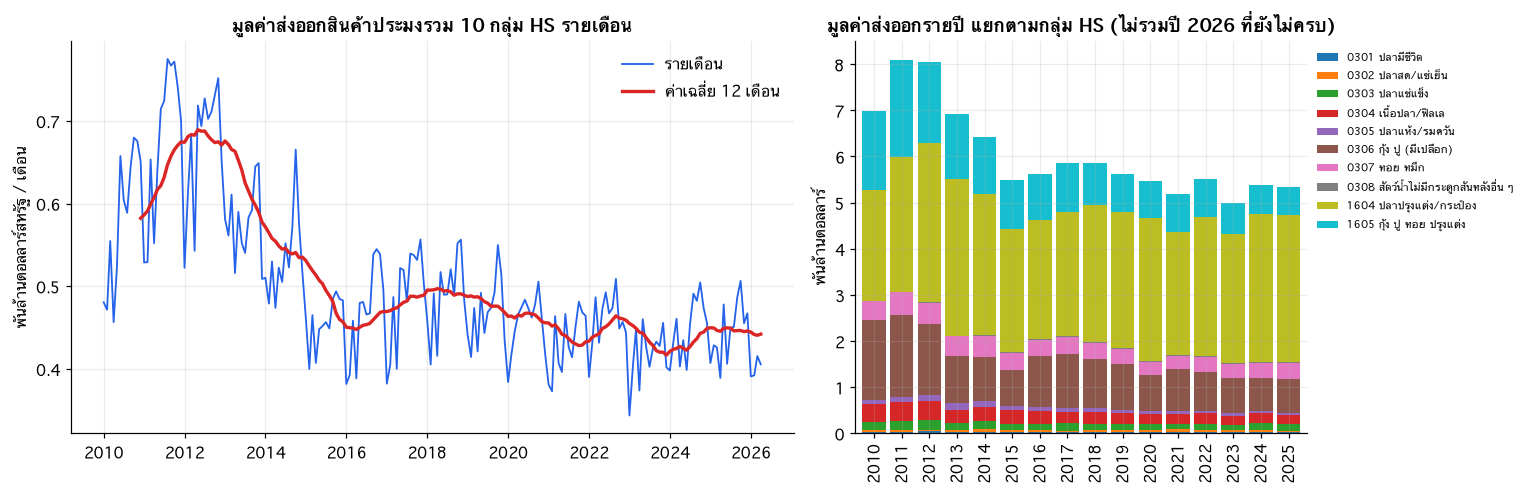

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
รวมทั้งปี (พันล้านดอลลาร์),6.99,8.10,8.05,6.93,6.42,5.48,5.63,5.87,5.87,5.62,5.47,5.19,5.50,5.00,5.39,5.35


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
tot = world.groupby("date").value_usd.sum() / 1e9
ax[0].plot(tot.index, tot.values, color=C["blue"], lw=1.2, label="รายเดือน")
ax[0].plot(tot.rolling(12).mean(), color=C["red"], lw=2.2, label="ค่าเฉลี่ย 12 เดือน")
ax[0].set(title="มูลค่าส่งออกสินค้าประมงรวม 10 กลุ่ม HS รายเดือน", ylabel="พันล้านดอลลาร์สหรัฐ / เดือน")
ax[0].legend(frameon=False)
yr = world[world.year < 2026].groupby(["year", "hs4"]).value_usd.sum().unstack() / 1e9
yr.rename(columns=HS4_NAME).plot.bar(stacked=True, ax=ax[1], width=.85, colormap="tab10")
ax[1].set(title="มูลค่าส่งออกรายปี แยกตามกลุ่ม HS (ไม่รวมปี 2026 ที่ยังไม่ครบ)", ylabel="พันล้านดอลลาร์", xlabel="")
ax[1].legend(fontsize=7, frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()
display((yr.sum(axis=1).rename("รวมทั้งปี (พันล้านดอลลาร์)").to_frame().T).round(2))

In [7]:
share = world[world.year == 2025].groupby("hs4").value_usd.sum().sort_values(ascending=False)
t = pd.DataFrame({"กลุ่ม HS": [HS4_NAME[h] for h in share.index], "มูลค่าปี 2025 (ล้านดอลลาร์)": (share / 1e6).values, "สัดส่วน %": (share / share.sum() * 100).values})
t["สะสม %"] = t["สัดส่วน %"].cumsum()
display(t)

,กลุ่ม HS,มูลค่าปี 2025 (ล้านดอลลาร์),สัดส่วน %,สะสม %
0,1604 ปลาปรุงแต่ง/กระป๋อง,"3,178.40",59.41,59.41
1,0306 กุ้ง ปู (มีเปลือก),724.53,13.54,72.96
2,1605 กุ้ง ปู หอย ปรุงแต่ง,627.85,11.74,84.69
3,0307 หอย หมึก,355.70,6.65,91.34
4,0304 เนื้อปลา/ฟิลเล,196.03,3.66,95.01
5,0303 ปลาแช่แข็ง,147.57,2.76,97.77
6,0305 ปลาแห้ง/รมควัน,45.78,0.86,98.62
7,0301 ปลามีชีวิต,30.17,0.56,99.19
8,0302 ปลาสด/แช่เย็น,29.52,0.55,99.74
9,0308 สัตว์น้ำไม่มีกระดูกสันหลังอื่น ๆ,13.99,0.26,100.00


### 📝 อ่านผล: แนวโน้มและโครงสร้างสินค้าส่งออก

**แนวโน้มมูลค่า**
- ยอดส่งออก 10 กลุ่ม HS รวมต่อปี **สูงสุดที่ 8.10 พันล้านดอลลาร์ (ปี 2011)** แล้วลดลงเหลือ **5.48 (ปี 2015)** จากนั้นเคลื่อนไหวอยู่ในช่วงแคบ ๆ ประมาณ **5.0–5.9** ตลอดปี 2016–2025 (ปี 2025 = 5.35)
- เส้นค่าเฉลี่ย 12 เดือนในกราฟซ้ายแสดงการ "ลดระดับ" ช่วงปี 2012–2015 อย่างชัดเจน ซึ่งเป็น **การเปลี่ยนโครงสร้าง (structural break)** ไม่ใช่ความผันผวนปกติ → ข้อมูลก่อนปี 2015 มี *ระดับและส่วนผสมสินค้าต่างจากปัจจุบัน* ถ้านำไปเทรนโมเดลโดยไม่ระวัง โมเดลจะเรียนรู้จากช่วงที่ไม่เหมือนปัจจุบัน
- กลุ่ม 0306 (กุ้ง ปู มีเปลือก) ในกราฟแท่งขวาหดลงชัดเจนเมื่อเทียบกับช่วงปี 2010–2012 (เหลือ 724.5 ล้านดอลลาร์ในปี 2025)

**โครงสร้างสินค้า (ปี 2025)**
- **1604 ปลาปรุงแต่ง/กระป๋อง = 59.4% ของมูลค่าทั้งหมด (3.18 พันล้านดอลลาร์)** กลุ่มเดียวใหญ่กว่าอีก 9 กลุ่มรวมกัน
- 3 กลุ่มแรก (1604, 0306, 1605) รวม **84.7%** และ 5 กลุ่มแรกรวม **95.0%** ส่วน 0301, 0302, 0308 แต่ละกลุ่มไม่ถึง 1%

**ผลต่อโปรเจกต์:** ถ้ารวมทุกสินค้าเข้าด้วยกันโดยไม่ปรับสเกล ผลการจัดกลุ่มและโมเดลจะถูกครอบงำด้วยกลุ่ม 1604 → ในขั้น Data Preparation ต้องแยกวิเคราะห์ตามกลุ่ม HS หรือใช้ค่าสัมพัทธ์ (สัดส่วน / การเปลี่ยนแปลง) / ใช้ log และควรจำกัดช่วงข้อมูลเทรนไปที่ **ปี 2015 เป็นต้นไป**

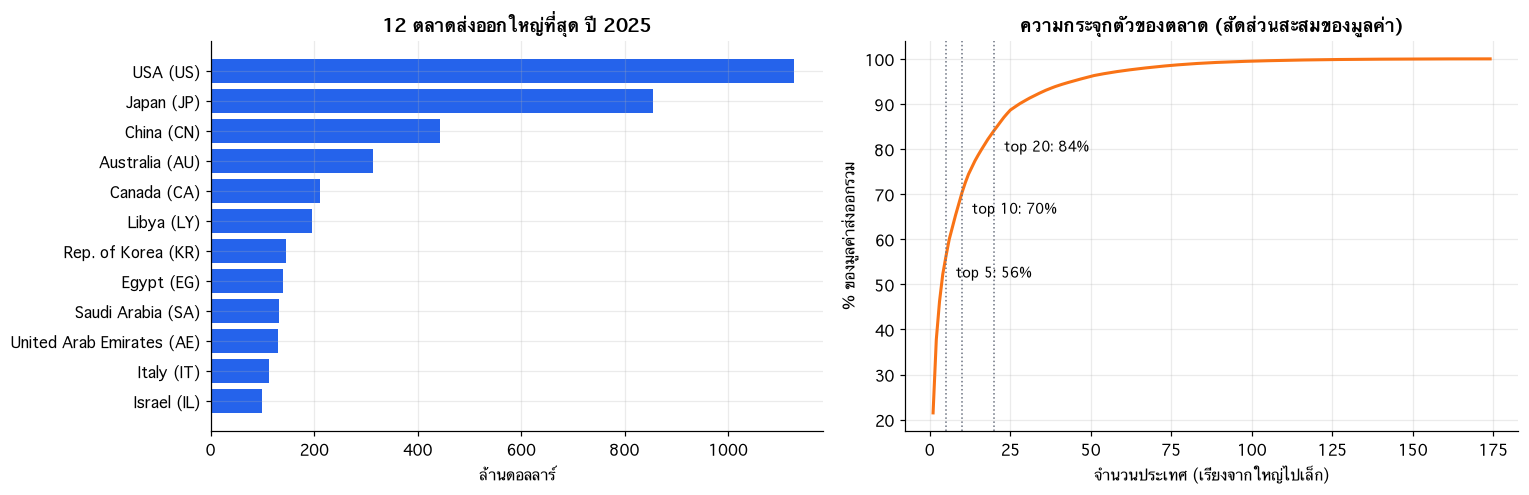

ปี 2025 มีประเทศคู่ค้า 174 ประเทศ/เขต
กลุ่มที่ไม่มีรหัสประเทศ ISO2 (เช่น 'nes' = ไม่ระบุประเทศ) คิดเป็น 1.9% ของมูลค่าปี 2025: {'Other Asia, nes': 100.9, 'Areas, nes': 0.0} (ล้านดอลลาร์)


In [8]:
# ประเทศคู่ค้า: ใครคือตลาดหลัก และกระจุกตัวแค่ไหน
p25 = part[(part.year == 2025) & part.partner_iso2.notna()].groupby(["partner_iso2", "partner_name"]).value_usd.sum().sort_values(ascending=False)
top = p25.head(12)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].barh([f"{n} ({i})" for (i, n) in top.index][::-1], top.values[::-1] / 1e6, color=C["blue"])
ax[0].set(title="12 ตลาดส่งออกใหญ่ที่สุด ปี 2025", xlabel="ล้านดอลลาร์")
cum = p25.cumsum() / p25.sum() * 100
ax[1].plot(range(1, len(cum) + 1), cum.values, color=C["orange"], lw=2)
for k in (5, 10, 20):
    ax[1].axvline(k, color=C["gray"], ls=":", lw=1); ax[1].annotate(f"top {k}: {cum.iloc[k-1]:.0f}%", (k, cum.iloc[k-1]), textcoords="offset points", xytext=(6, -14), fontsize=9)
ax[1].set(title="ความกระจุกตัวของตลาด (สัดส่วนสะสมของมูลค่า)", xlabel="จำนวนประเทศ (เรียงจากใหญ่ไปเล็ก)", ylabel="% ของมูลค่าส่งออกรวม")
plt.tight_layout(); plt.show()
print(f"ปี 2025 มีประเทศคู่ค้า {len(p25)} ประเทศ/เขต")
nes = part[(part.year == 2025) & part.partner_iso2.isna()].groupby("partner_name").value_usd.sum().sort_values(ascending=False)
nes_share = nes.sum() / part[part.year == 2025].value_usd.sum()
print(f"กลุ่มที่ไม่มีรหัสประเทศ ISO2 (เช่น 'nes' = ไม่ระบุประเทศ) คิดเป็น {nes_share:.1%} ของมูลค่าปี 2025:", {k: round(v / 1e6, 1) for k, v in nes.head(5).items()}, "(ล้านดอลลาร์)")

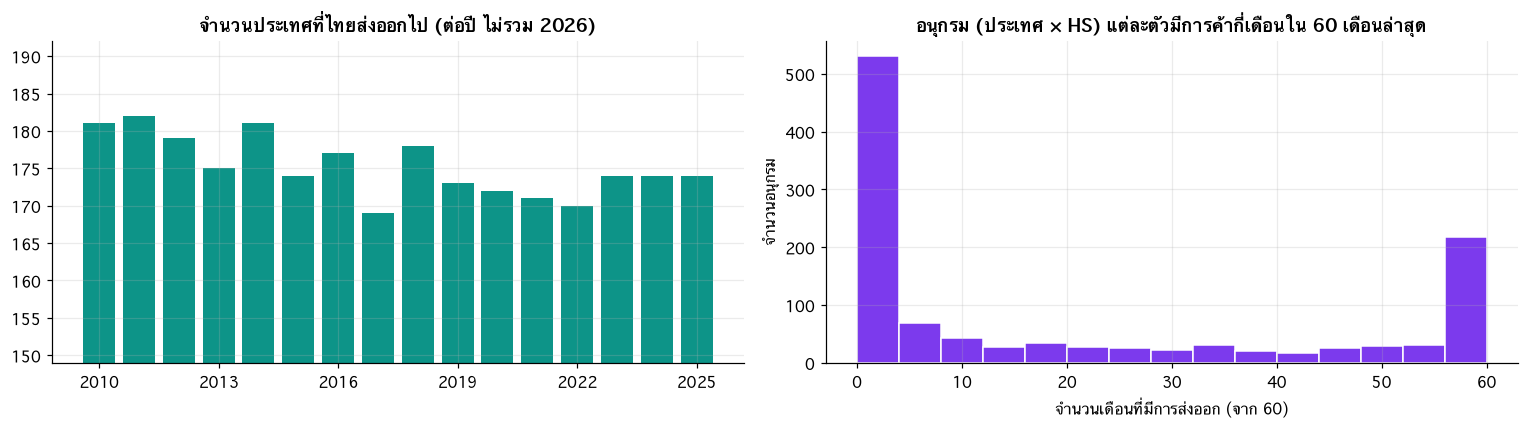

อนุกรม (ประเทศ × HS) ที่เคยมีการค้าทั้งหมด: 1,148


,เกณฑ์ (เดือนที่มีการค้าจาก 60),จำนวนอนุกรม,สัดส่วนมูลค่าที่ครอบคลุม %
0,>= 24,417,99.54
1,>= 36,340,98.83
2,>= 48,278,98.30
3,>= 58,200,95.51


In [9]:
# จำนวนตลาดที่ส่งออกไปจริงในแต่ละปี และความต่อเนื่องของ "อนุกรมประเทศ × HS"
n_partner = part[part.partner_iso2.notna() & (part.year < 2026)].groupby("year").partner_iso2.nunique()
pair = part[part.partner_iso2.notna()].pivot_table(index=["hs4", "partner_iso2"], columns="date", values="value_usd", aggfunc="sum").fillna(0)
last60 = pair.iloc[:, -60:]
active = (last60 > 0).sum(axis=1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(n_partner.index, n_partner.values, color=C["teal"]); ax[0].set(title="จำนวนประเทศที่ไทยส่งออกไป (ต่อปี ไม่รวม 2026)", ylim=(n_partner.min() - 20, n_partner.max() + 10), xticks=n_partner.index[::3])
ax[1].hist(active, bins=range(0, 62, 4), color=C["purple"], edgecolor="white")
ax[1].set(title="อนุกรม (ประเทศ × HS) แต่ละตัวมีการค้ากี่เดือนใน 60 เดือนล่าสุด", xlabel="จำนวนเดือนที่มีการส่งออก (จาก 60)", ylabel="จำนวนอนุกรม")
plt.tight_layout(); plt.show()
k = pd.DataFrame({"เกณฑ์ (เดือนที่มีการค้าจาก 60)": [">= 24", ">= 36", ">= 48", ">= 58"], "จำนวนอนุกรม": [(active >= k).sum() for k in (24, 36, 48, 58)],
                  "สัดส่วนมูลค่าที่ครอบคลุม %": [last60[active >= k].values.sum() / last60.values.sum() * 100 for k in (24, 36, 48, 58)]})
print(f"อนุกรม (ประเทศ × HS) ที่เคยมีการค้าทั้งหมด: {len(pair):,}")
display(k)

### 📝 อ่านผล: ประเทศคู่ค้าและความต่อเนื่องของอนุกรม

**ความกระจุกตัวของตลาด (ปี 2025: 174 ประเทศ/เขต)**
- ตลาดใหญ่สุดคือ **สหรัฐฯ (ราว 1.1 พันล้านดอลลาร์)** ตามด้วยญี่ปุ่น (ราว 0.85) จีน (ราว 0.44) ออสเตรเลีย (ราว 0.31) และแคนาดา (ราว 0.21)
- **5 ตลาดแรก = 56%, 10 ตลาดแรก = 70%, 20 ตลาดแรก = 84%** ของมูลค่า ที่เหลือราว 150 ประเทศแบ่งกันเพียง 16%
- ใน 12 อันดับแรกมีประเทศตะวันออกกลาง/แอฟริกาเหนือหลายแห่ง (ลิเบีย อียิปต์ ซาอุดีอาระเบีย สหรัฐอาหรับเอมิเรตส์ อิสราเอล) ซึ่งต่างจากภาพจำที่ตลาดหลักคือสหรัฐฯ/ญี่ปุ่น/จีน อย่างเดียว → เป็นเหตุผลให้ **จัดกลุ่มตลาด** น่าสนใจ
- จำนวนประเทศที่ส่งออกไปต่อปีค่อนข้างนิ่ง (ราว 169–182 ประเทศ ตลอดปี 2010–2025) แปลว่า "ชุดของตลาด" ค่อนข้างเสถียร

**ความต่อเนื่องของอนุกรม (ประเทศ × HS) มีทั้งหมด 1,148 อนุกรม**
- กราฟขวาเป็น 2 กลุ่มชัดเจน: **ราว 530 อนุกรมมีการค้าไม่เกิน 3 เดือนจาก 60 เดือนล่าสุด** (การค้าประปราย) กับ **ราว 217 อนุกรมที่มีการค้าเกือบทุกเดือน (≥ 56)**
- อนุกรมที่มีการค้า ≥ 36 เดือน (จาก 60) มี **340 อนุกรม แต่ครอบคลุม 98.8% ของมูลค่า** นั่นคือ **ตัดอนุกรมประปรายราว 800 อนุกรมทิ้งได้ โดยเสียมูลค่าเพียง 1.2%**
- กลุ่มที่ไม่มีรหัสประเทศ ISO2 (เช่น "Other Asia, nes") คิดเป็น **1.9%** ของมูลค่าปี 2025 (ตามปกติ UN Comtrade ใช้ชื่อกลุ่มนี้แทนไต้หวัน — ควรยืนยัน) จึง join กับข้อมูลเศรษฐกิจรายประเทศไม่ได้

**ผลต่อโปรเจกต์:** ขนาดข้อมูลสำหรับ clustering และ classification เพียงพอ (340 อนุกรมที่เสถียร × 183 เดือน ≈ 62,000 แถว) และตัวเลขที่ต้องระวังคือ ต้องกำหนดเกณฑ์ "อนุกรมที่ใช้ได้" ตั้งแต่ต้นไม่ให้ปะปนกับตลาดประปราย

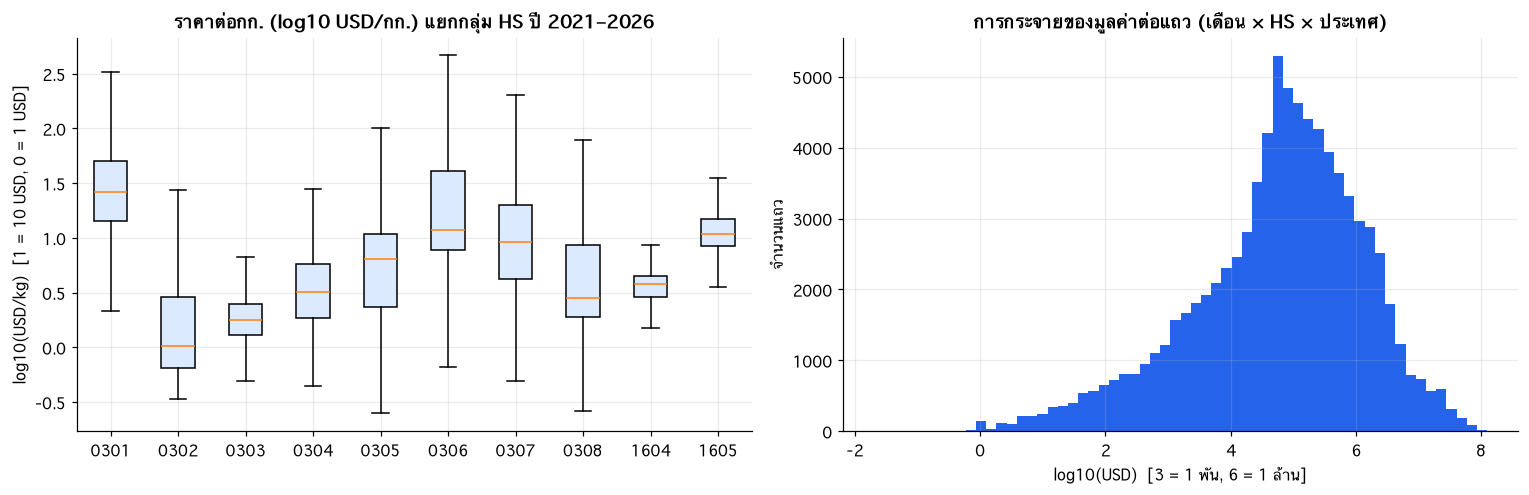

,count,min,50%,mean,max
hs4,,,,,
0301 ปลามีชีวิต,"3,853.00",0.19,26.49,47.74,"3,765.82"
0302 ปลาสด/แช่เย็น,545.00,0.33,1.03,2.49,77.23
0303 ปลาแช่แข็ง,"1,721.00",0.12,1.77,2.32,79.17
0304 เนื้อปลา/ฟิลเล,"1,509.00",0.24,3.18,4.40,46.18
0305 ปลาแห้ง/รมควัน,"1,726.00",0.03,6.39,9.11,"1,899.99"
0306 กุ้ง ปู (มีเปลือก),"3,272.00",0.22,11.89,120.72,"10,105.19"
0307 หอย หมึก,"2,656.00",0.16,9.10,18.24,804.21
0308 สัตว์น้ำไม่มีกระดูกสันหลังอื่น ๆ,570.00,0.16,2.84,14.93,980.01
1604 ปลาปรุงแต่ง/กระป๋อง,"7,351.00",0.25,3.80,3.88,43.81


In [10]:
# หน่วยราคา (USD ต่อกก.) และการกระจายของมูลค่า
pm = part[(part.net_weight_kg > 0) & (part.value_usd > 0) & (part.year >= 2021)].copy()
pm["usd_per_kg"] = pm.value_usd / pm.net_weight_kg
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
order = SEAFOOD_HS4
ax[0].boxplot([np.log10(pm[pm.hs4 == h].usd_per_kg) for h in order], showfliers=False, patch_artist=True, boxprops={"facecolor": "#dbeafe"}); ax[0].set_xticklabels(order)
ax[0].set(title="ราคาต่อกก. (log10 USD/กก.) แยกกลุ่ม HS ปี 2021–2026", ylabel="log10(USD/kg)  [1 = 10 USD, 0 = 1 USD]")
ax[1].hist(np.log10(part.value_usd[part.value_usd > 0]), bins=60, color=C["blue"])
ax[1].set(title="การกระจายของมูลค่าต่อแถว (เดือน × HS × ประเทศ)", xlabel="log10(USD)  [3 = 1 พัน, 6 = 1 ล้าน]", ylabel="จำนวนแถว")
plt.tight_layout(); plt.show()
display(pm.groupby("hs4").usd_per_kg.describe(percentiles=[.5]).rename(index=HS4_NAME)[["count", "min", "50%", "mean", "max"]])

### 📝 อ่านผล: ราคาต่อกิโลกรัมและการกระจายของมูลค่า

- ราคาต่อกก. ต่างกันเป็นสิบเท่าตามชนิดสินค้า: **1604 ปลากระป๋อง มัธยฐาน 3.80 USD/กก. (ช่วงแคบ: เฉลี่ย 3.88, สูงสุด 43.8)**, 0303 ปลาแช่แข็ง 1.77, 0302 ปลาสด/แช่เย็น 1.03, 0306 กุ้ง ปู 11.89, 0307 หอย หมึก 9.10, 0301 ปลามีชีวิต 26.49 (สูงสุดในกลุ่ม; ยังไม่ได้ตรวจว่าเป็นสินค้าชนิดใด)
- **ค่าสุดโต่งมีมาก:** 0306 มัธยฐาน 11.89 แต่ *ค่าเฉลี่ย 120.72 และสูงสุด 10,105 USD/กก.* บ่งว่ามีแถวที่น้ำหนักน้อยมากแต่มูลค่าสูง (ยังไม่ได้ตรวจว่าเป็นสินค้าอะไร) → ถ้าใช้ราคาต่อกก. เป็น feature ต้องใช้ *มัธยฐาน* หรือจำกัดค่าสุดโต่ง (winsorize) ไม่ใช่ค่าเฉลี่ยตรง ๆ
- มูลค่าต่อแถว (เดือน × HS × ประเทศ) กระจายตัวกว้างมาก ตั้งแต่ 0.02 ถึง 323.9 ล้านดอลลาร์ แต่รูปร่างของ log10 ค่อนข้างเป็นระฆังคว่ำ (มัธยฐาน 85,743 USD) → **ควรใช้ log หรือเปรียบเทียบแบบสัมพัทธ์** ไม่ใช้ค่าดิบ
- คอลัมน์ `net_weight_kg` ว่างเพียง 0.2% ใช้คำนวณราคาต่อหน่วยได้ ส่วน `qty_unit` ว่าง 100% และ `cif_usd` ว่างครึ่งหนึ่ง ไม่ควรใช้

### 2.2.1 ฤดูกาลและความผันผวน (ข้อมูลเหล่านี้ใช้ตัดสินว่าโจทย์พยากรณ์รายเดือนเป็นไปได้หรือไม่)

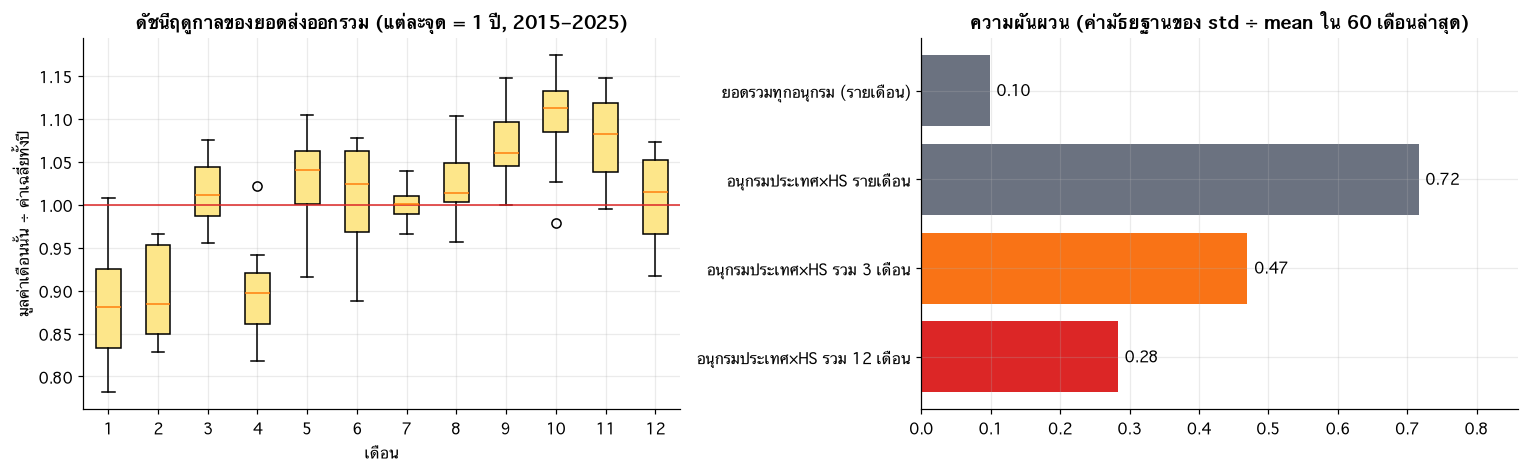

ดัชนีฤดูกาลเฉลี่ยรายเดือน (1.00 = ค่าเฉลี่ยปี): {1: 0.88, 2: 0.9, 3: 1.02, 4: 0.9, 5: 1.03, 6: 1.01, 7: 1.0, 8: 1.03, 9: 1.07, 10: 1.1, 11: 1.08, 12: 1.0}


In [11]:
# ดัชนีฤดูกาลของยอดรวม: มูลค่าเดือนนั้น / ค่าเฉลี่ยของปีนั้น (2015–2025)
W = world[world.year.between(2015, 2025)].groupby(["year", "month"]).value_usd.sum().unstack()
idx = W.div(W.mean(axis=1), axis=0)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
ax[0].boxplot([idx[m] for m in range(1, 13)], patch_artist=True, boxprops={"facecolor": "#fde68a"}); ax[0].set_xticklabels(range(1, 13))
ax[0].axhline(1, color=C["red"], lw=1)
ax[0].set(title="ดัชนีฤดูกาลของยอดส่งออกรวม (แต่ละจุด = 1 ปี, 2015–2025)", xlabel="เดือน", ylabel="มูลค่าเดือนนั้น ÷ ค่าเฉลี่ยทั้งปี")
# เทียบความผันผวนระดับต่าง ๆ
sel = pair[active >= 36]
cv = lambda M: (M.std(axis=1) / M.mean(axis=1)).median()
m1 = sel.iloc[:, -60:]
m3 = sel.T.rolling(3).sum().T.iloc[:, -60:]
m12 = sel.T.rolling(12).sum().T.iloc[:, -60:]
lv = pd.Series({"ยอดรวมทุกอนุกรม (รายเดือน)": W.stack().std() / W.stack().mean(), "อนุกรมประเทศ×HS รายเดือน": cv(m1),
                "อนุกรมประเทศ×HS รวม 3 เดือน": cv(m3), "อนุกรมประเทศ×HS รวม 12 เดือน": cv(m12)})
ax[1].barh(lv.index[::-1], lv.values[::-1], color=[C["gray"], C["gray"], C["orange"], C["red"]][::-1])
for i, v in enumerate(lv.values[::-1]): ax[1].text(v + .01, i, f"{v:.2f}", va="center")
ax[1].set(title="ความผันผวน (ค่ามัธยฐานของ std ÷ mean ใน 60 เดือนล่าสุด)", xlim=(0, lv.max() * 1.2))
plt.tight_layout(); plt.show()
print("ดัชนีฤดูกาลเฉลี่ยรายเดือน (1.00 = ค่าเฉลี่ยปี):", idx.mean().round(2).to_dict())

autocorrelation ของ 340 อนุกรมที่มีการค้าสม่ำเสมอ (ค่ามัธยฐาน)


,ระดับ (มีแนวโน้มปนอยู่),หลังตัดแนวโน้ม (diff)
lag 1 (เดือนก่อน),0.30,-0.46
lag 12 (เดือนเดียวกันปีก่อน),0.12,0.05


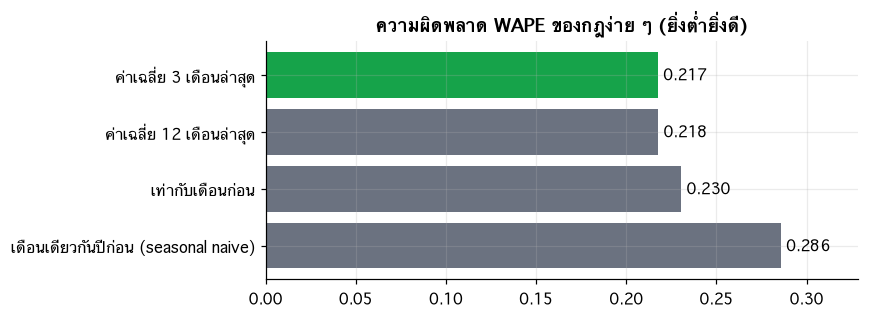

,WAPE
ค่าเฉลี่ย 3 เดือนล่าสุด,0.217
ค่าเฉลี่ย 12 เดือนล่าสุด,0.218
เท่ากับเดือนก่อน,0.230
เดือนเดียวกันปีก่อน (seasonal naive),0.286


In [12]:
# สัญญาณที่พยากรณ์ได้ในข้อมูล: autocorrelation (หลังตัดแนวโน้มด้วย first-difference ของ log)
def ac(x, k):
    x = x[~np.isnan(x)]; x = x - x.mean(); d = (x * x).sum()
    return (x[k:] * x[:-k]).sum() / d if d > 0 and len(x) > k + 2 else np.nan

L = np.log1p(sel.iloc[:, 60:])
Dd = L.diff(axis=1).iloc[:, 1:]
acf = pd.DataFrame({
    "ระดับ (มีแนวโน้มปนอยู่)": [L.apply(lambda r: ac(r.values, 1), axis=1).median(), L.apply(lambda r: ac(r.values, 12), axis=1).median()],
    "หลังตัดแนวโน้ม (diff)":    [Dd.apply(lambda r: ac(r.values, 1), axis=1).median(), Dd.apply(lambda r: ac(r.values, 12), axis=1).median()],
}, index=["lag 1 (เดือนก่อน)", "lag 12 (เดือนเดียวกันปีก่อน)"])
print(f"autocorrelation ของ {len(sel)} อนุกรมที่มีการค้าสม่ำเสมอ (ค่ามัธยฐาน)")
display(acf)

# กฎพยากรณ์ง่าย ๆ ทำนายเดือนถัดไป: ดูว่ากฎไหนผิดพลาดน้อยสุดบน 100 อนุกรมใหญ่ 36 เดือนล่าสุด
top100 = sel.sum(axis=1).sort_values(ascending=False).head(100).index
T_ = pair.loc[top100].values; n = T_.shape[1]; tm = range(n - 36, n)
def wape(f):
    a = np.concatenate([T_[:, t] for t in tm]); p = np.concatenate([f(t) for t in tm]); return np.abs(a - p).sum() / a.sum()
rules = pd.Series({
    "เท่ากับเดือนก่อน": wape(lambda t: T_[:, t - 1]),
    "ค่าเฉลี่ย 3 เดือนล่าสุด": wape(lambda t: T_[:, t - 3:t].mean(axis=1)),
    "ค่าเฉลี่ย 12 เดือนล่าสุด": wape(lambda t: T_[:, t - 12:t].mean(axis=1)),
    "เดือนเดียวกันปีก่อน (seasonal naive)": wape(lambda t: T_[:, t - 12]),
}).sort_values()
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(rules.index[::-1], rules.values[::-1], color=[C["gray"]] * 3 + [C["green"]]); ax.set(title="ความผิดพลาด WAPE ของกฎง่าย ๆ (ยิ่งต่ำยิ่งดี)", xlim=(0, rules.max() * 1.15))
for i, v in enumerate(rules.values[::-1]): ax.text(v + .003, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()
display(rules.round(3).map("{:.3f}".format).rename("WAPE").to_frame())

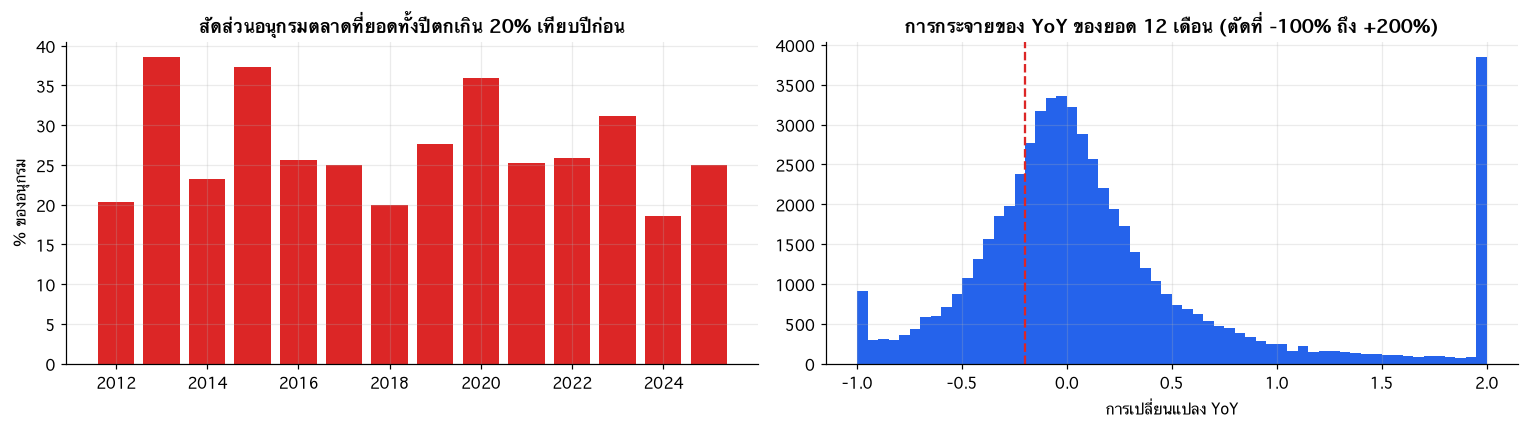

สัดส่วนอนุกรม-เดือนที่ยอด 12 เดือนตกเกิน 20% (YoY): 26.9% จากทั้งหมด 55,156 จุด
โอกาสที่ 6 เดือนต่อมายังตกเกิน 20%: ถ้าตอนนี้ตกอยู่ = 54.1% | โดยรวม = 27.3%  (หมายเหตุ: หน้าต่าง 12 เดือนซ้อนกัน 6 เดือน ตัวเลขนี้จึงสูงกว่าความเป็นจริงส่วนหนึ่ง)


In [13]:
# ตลาดที่ "ยอดตก" เกิดบ่อยแค่ไหน และตกต่อเนื่องไหม? (ใช้ยอดรวม 12 เดือนเพื่อลดความผันผวนรายเดือน)
r12 = sel.T.rolling(12).sum().T
yoy = r12 / r12.shift(12, axis=1) - 1                       # ยอด 12 เดือนล่าสุด เทียบ 12 เดือนก่อนหน้า
dec = [c for c in yoy.columns if c.month == 12 and c.year >= 2012]
drop_by_year = pd.Series({c.year: (yoy[c] < -0.2).mean() for c in dec})
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(drop_by_year.index, drop_by_year.values * 100, color=C["red"]); ax[0].set(title="สัดส่วนอนุกรมตลาดที่ยอดทั้งปีตกเกิน 20% เทียบปีก่อน", ylabel="% ของอนุกรม", xticks=drop_by_year.index[::2])
ax[1].hist(yoy.stack().clip(-1, 2), bins=60, color=C["blue"]); ax[1].axvline(-0.2, color=C["red"], ls="--"); ax[1].set(title="การกระจายของ YoY ของยอด 12 เดือน (ตัดที่ -100% ถึง +200%)", xlabel="การเปลี่ยนแปลง YoY")
plt.tight_layout(); plt.show()
now, later = yoy.iloc[:, 12:-6].values, yoy.iloc[:, 18:].values
m_ = np.isfinite(now) & np.isfinite(later)
p_all = (later[m_] < -0.2).mean(); p_cond = (later[m_ & (now < -0.2)] < -0.2).mean()
print(f"สัดส่วนอนุกรม-เดือนที่ยอด 12 เดือนตกเกิน 20% (YoY): {(now[m_] < -0.2).mean():.1%} จากทั้งหมด {m_.sum():,} จุด")
print(f"โอกาสที่ 6 เดือนต่อมายังตกเกิน 20%: ถ้าตอนนี้ตกอยู่ = {p_cond:.1%} | โดยรวม = {p_all:.1%}  (หมายเหตุ: หน้าต่าง 12 เดือนซ้อนกัน 6 เดือน ตัวเลขนี้จึงสูงกว่าความเป็นจริงส่วนหนึ่ง)")

### 📝 อ่านผล: ฤดูกาลและความผันผวน — ข้อมูลช่วยตอบว่าพยากรณ์รายเดือนทำได้แค่ไหน

**1) ฤดูกาลของยอดรวม: มีแต่อ่อน**
- ดัชนีฤดูกาลเฉลี่ยอยู่ระหว่าง **0.88 (ม.ค.) ถึง 1.10 (ต.ค.)** เดือน ม.ค., ก.พ., เม.ย. ต่ำกว่าเฉลี่ย (0.88, 0.90, 0.90) และ ก.ย.–พ.ย. สูงกว่าเฉลี่ย (1.07, 1.10, 1.08) แต่กล่อง (ช่วงของแต่ละปี) ของหลายเดือนซ้อนกัน แปลว่าแม้รูปแบบจะพอเห็น ก็ไม่แน่นอนพอที่จะทำนายค่าเฉพาะเดือนได้ชัด

**2) ความผันผวนลดลงเมื่อรวมช่วงเวลายาวขึ้น (กราฟขวา)**
| ระดับการรวม | ความผันผวน (std ÷ mean) |
|---|---|
| ยอดรวมทุกอนุกรม รายเดือน | 0.10 |
| อนุกรมประเทศ×HS รายเดือน | **0.72** |
| อนุกรมประเทศ×HS รวม 3 เดือน | 0.47 |
| อนุกรมประเทศ×HS รวม 12 เดือน | **0.28** |

ระดับ "ประเทศ × HS รายเดือน" สั่นไหวมากถึง 0.72 แต่เมื่อรวม 12 เดือนเหลือ 0.28 → **สัญญาณชัดขึ้นเมื่อใช้ช่วงเวลายาว**

**3) Autocorrelation (ค่ามัธยฐานของ 340 อนุกรม)**
- หลังตัดแนวโน้ม **lag 1 = −0.46**: เดือนที่สูงมักตามด้วยเดือนที่ต่ำ (ความผันผวนสุ่มที่เด้งกลับ) และ **lag 12 = 0.05**: *แทบไม่มีความสัมพันธ์กับเดือนเดียวกันของปีก่อน* → ในระดับอนุกรมย่อย ไม่มีฤดูกาลที่ทำนายได้

**4) กฎพยากรณ์ง่าย ๆ (100 อนุกรมใหญ่ 36 เดือนล่าสุด ทำนายเดือนถัดไป)**
- ค่าเฉลี่ย 3 หรือ 12 เดือนล่าสุด **WAPE 0.220** (ดีสุด) · เท่ากับเดือนก่อน 0.233 · **seasonal naive (เดือนเดียวกันปีก่อน) 0.288 แย่สุด**
- สอดคล้องกับข้อ 3: การย้อนดูปีก่อนไม่ช่วย ค่าเฉลี่ยง่าย ๆ ทำได้ดีกว่า

**ข้อสรุปต่อโจทย์** → โจทย์ *พยากรณ์ยอดเดือนถัดไปรายประเทศ × HS* มีเพดานความแม่นยำใกล้ WAPE ≈ 0.22 ของกฎง่าย ๆ ไม่มีที่ว่างให้ ML ชนะได้ชัดเจน (ยังไม่ได้ทดสอบโมเดลจริง นี่คือการประเมินจากข้อมูล) → จึง **ตั้งความคาดหวังล่วงหน้า** ใน Goal 1 (ส่วน 1.4) ว่าผลที่พอเป็นไปได้คือ ML ใกล้เคียงหรือไม่ชนะ baseline และออกแบบการทดสอบให้รายงานผลตามจริงได้ไม่ว่าจะออกมาอย่างไร

**5) โจทย์ Early Warning (ยอดทั้งปีตกเกิน 20%)**
- **26.9% ของจุด (อนุกรม × เดือน) มียอด 12 เดือนตกเกิน 20% เทียบปีก่อน** (จาก 55,156 จุด) คลาสบวกไม่ได้หายากมาก ไม่ต้องจัดการ imbalance รุนแรง
- **สัดส่วนต่างกันมากตามปี:** สูงที่ปี 2013 (≈ 39%), 2015 (≈ 37%), 2020 (≈ 36%), 2023 (≈ 31%) และต่ำที่สุดปี 2024 (≈ 19%) → การตกของตลาดมักเกิดเป็นช่วงที่พร้อมกันหลายตลาด (ผลกระทบตลาดโลกหรือเหตุการณ์ใหญ่) ดังนั้น **ต้องแบ่งข้อมูลตามเวลาและตรวจโมเดลข้ามหลายช่วงปี** ไม่ใช่แค่ปีเดียว
- ถ้าตอนนี้ตกอยู่ โอกาสที่ 6 เดือนต่อมายังตกเกิน 20% = **54.1%** เทียบกับ 27.3% โดยรวม แสดงว่ามีความต่อเนื่องของการตกอยู่ แต่ *ส่วนหนึ่งเกิดจากหน้าต่าง 12 เดือนที่ซ้อนกัน* จึงยังไม่ใช่หลักฐานว่าทำนายได้จริง โมเดลต้องชนะ baseline "ตกอยู่ → ตกต่อ" นี้ให้ได้

## 2.3 ข้อมูลกรมประมง: นำเข้า-ส่งออกรายเดือนตามรหัส HS 11 หลัก (`trade_hs`)

ข้อมูลชุดแรกที่ได้รับ (ชุด `impexp_product`) อ่านจากไฟล์ดิบ 2 ไฟล์ที่แยกปีแล้ว เพื่อให้เห็นปัญหาของข้อมูลต้นฉบับ

In [14]:
th = pd.concat([rd(f, dtype={"heading11": str}) for f in sorted((DATA / "trade").glob("dof_trade_hs_monthly_*.csv"))], ignore_index=True)
th["date"] = pd.to_datetime(dict(year=th.year - 543, month=th.month, day=1))   # ปี พ.ศ. -> ค.ศ.
th["flow"] = th.tradeflow.map({1: "นำเข้า", 2: "ส่งออก"})
th["hs4"] = th.heading11.str[:4]
print("ขนาด:", th.shape)
display(th.head(8))

ขนาด: (65235, 16)


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,fishName,productDetailTH,ETL_DATE,date,flow,hs4
0,2568,1,01062000002,SC,เซเชลส์,200,20,169196,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-01-01,นำเข้า,0106
1,2568,2,01062000002,BJ,เบนิน,10,60,17170,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
2,2568,2,01062000002,KE,เคนยา,25,100,39490,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
3,2568,2,01062000002,ZM,แซมเบีย,45,450,128875,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
4,2568,2,01062000002,MU,มอริเชียส,20,100,113903,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
5,2568,2,01062000002,SC,เซเชลส์,420,150,417638,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
6,2568,3,01062000002,ET,เอธิโอเปีย,380,50,296224,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-03-01,นำเข้า,0106
7,2568,3,01062000002,QA,กาตาร์,7,80,15584,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-03-01,นำเข้า,0106


In [15]:
print("ชนิดข้อมูลและค่าว่าง")
display(pd.DataFrame({"dtype": th.dtypes.astype(str), "ค่าว่าง": th.isna().sum(), "ค่าไม่ซ้ำ": th.nunique()}))
display(th[["weight", "quantity", "price"]].describe(percentiles=[.5, .95]).T)
print(f"ช่วงเวลา: {th.date.min():%b %Y} – {th.date.max():%b %Y} ({th.date.nunique()} เดือน)")
print("จำนวนแถวต่อทิศทาง:", th.flow.value_counts().to_dict(), "| ประเทศ:", th.countryID.nunique(), "| HS11:", th.heading11.nunique(), "| HS4:", th.hs4.nunique())

ชนิดข้อมูลและค่าว่าง


,dtype,ค่าว่าง,ค่าไม่ซ้ำ
year,int64,0,2
month,int64,0,12
heading11,str,0,458
countryID,str,0,199
countryNameTH,str,0,199
weight,int64,0,24523
quantity,int64,0,24836
price,int64,0,57344
tradeflow,int64,0,2
productDetailEN,str,0,266


,count,mean,std,min,50%,95%,max
weight,"65,235.00","88,291.40","439,638.97",0.00,"2,894.00","334,522.30","18,684,570.00"
quantity,"65,235.00","281,232.10","10,237,565.14",0.00,"3,590.00","600,000.00","2,375,725,750.00"
price,"65,235.00","8,957,959.17","40,398,071.77",0.00,"583,249.00","34,654,157.60","1,294,268,120.00"


ช่วงเวลา: Jan 2025 – Jul 2026 (19 เดือน)
จำนวนแถวต่อทิศทาง: {'ส่งออก': 44420, 'นำเข้า': 20815} | ประเทศ: 199 | HS11: 458 | HS4: 25


In [16]:
# ตรวจปัญหาคุณภาพของข้อมูลดิบ
key = ["year", "month", "heading11", "countryID", "tradeflow"]
issues = pd.Series({
    "แถวซ้ำทั้งแถว": int(th.duplicated(subset=[c for c in th.columns if c != "date"]).sum()),
    "แถวที่ key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำกัน (ค่าต่างกัน)": int(th.drop_duplicates(subset=[c for c in th.columns if c != "date"]).duplicated(key, keep=False).sum()),
    "รหัสประเทศ 'yy' (ไม่ใช่ประเทศ)": int((th.countryID == "yy").sum()),
    "รายละเอียดสินค้า (อังกฤษ) เป็น '(blank)'": int((th.productDetailEN == "(blank)").sum()),
    "รายละเอียดสินค้า (อังกฤษ) เป็น 'Other'": int((th.productDetailEN == "Other").sum()),
    "น้ำหนัก = 0": int((th.weight == 0).sum()), "มูลค่า = 0": int((th.price == 0).sum()),
})
display(issues.rename("จำนวนแถว").to_frame().assign(**{"% ของทั้งหมด": lambda d: (d["จำนวนแถว"] / len(th) * 100).round(2)}))
ex = th[th.duplicated(key, keep=False)].sort_values(key).head(6)[["year", "month", "heading11", "countryID", "tradeflow", "weight", "quantity", "price", "productDetailEN"]]
print("ตัวอย่าง key ซ้ำ (ไม่มีคอลัมน์ที่บอกว่าแต่ละแถวต่างกันอย่างไร):"); display(ex)

,จำนวนแถว,% ของทั้งหมด
แถวซ้ำทั้งแถว,12,0.02
"แถวที่ key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำกัน (ค่าต่างกัน)",15659,24.00
รหัสประเทศ 'yy' (ไม่ใช่ประเทศ),38,0.06
รายละเอียดสินค้า (อังกฤษ) เป็น '(blank)',13710,21.02
รายละเอียดสินค้า (อังกฤษ) เป็น 'Other',12905,19.78
น้ำหนัก = 0,719,1.10
มูลค่า = 0,17,0.03


ตัวอย่าง key ซ้ำ (ไม่มีคอลัมน์ที่บอกว่าแต่ละแถวต่างกันอย่างไร):


,year,month,heading11,countryID,tradeflow,weight,quantity,price,productDetailEN
211,2568,1,03011191000,IT,2,24,875,12959,- - - - Koi carp (Cyprinus carpio)
220,2568,1,03011191000,IT,2,1,60,16957,- - - - Koi carp (Cyprinus carpio)
202,2568,1,03011191000,KR,2,2,140,357,- - - - Koi carp (Cyprinus carpio)
217,2568,1,03011191000,KR,2,6,670,21530,- - - - Koi carp (Cyprinus carpio)
636,2568,1,03011192000,CZ,2,5,1700,2769,- - - - Goldfish (Carassius auratus)
638,2568,1,03011192000,CZ,2,7,2754,75189,- - - - Goldfish (Carassius auratus)


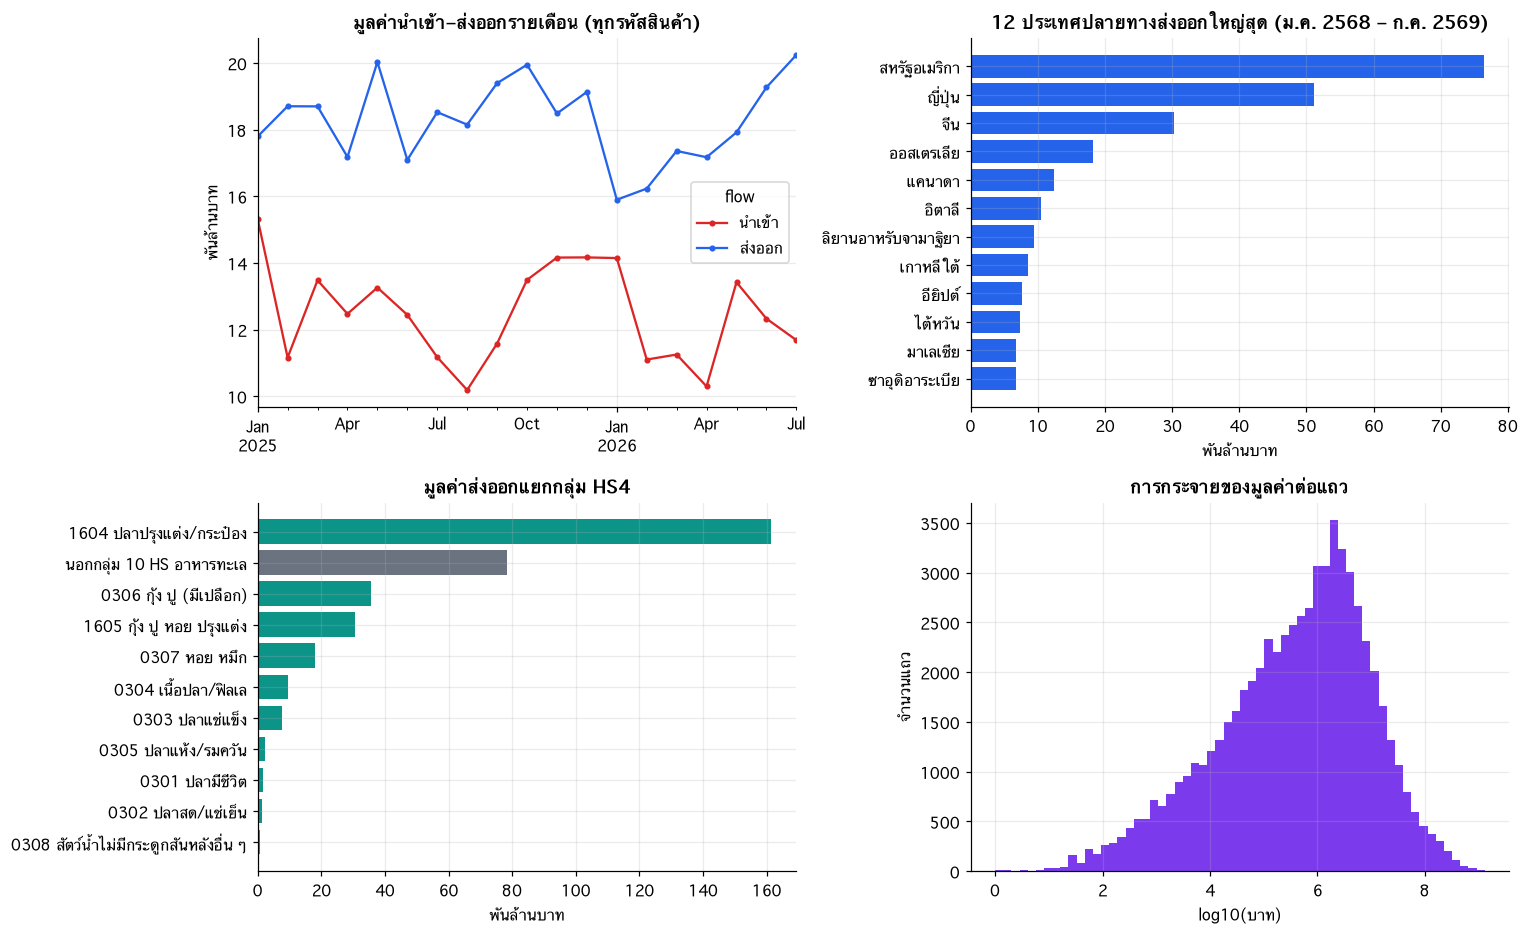

สินค้านอกกลุ่ม 10 HS อาหารทะเลที่อยู่ในไฟล์นี้ (6 อันดับแรก):


,มูลค่า_ล้านบาท,ชื่อสินค้า
hs4,,
2309,"48,874.85",อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้าออกไม่ได้
2103,"17,327.23",น้ำปลา
2301,"8,180.27",ปลาป่นที่มีโปรตีนน้อยกว่าร้อยละ 60
1504,"1,275.26",น้ำมันตับปลาและแฟรกชั่นที่บริโภคได้
0511,"1,178.21",สัตว์ในตอนที่3 ที่ไม่มีชีวิต
1603,548.12,สิ่งสกัดและน้ำคั้นจากปลาหรือสัตว์น้ำไม่มีกระดูกสันหลังอื่นๆ


In [17]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8.6))
m = th.groupby(["date", "flow"]).price.sum().unstack() / 1e9
m.plot(ax=ax[0, 0], color=[C["red"], C["blue"]], marker="o", ms=3); ax[0, 0].set(title="มูลค่านำเข้า–ส่งออกรายเดือน (ทุกรหัสสินค้า)", ylabel="พันล้านบาท", xlabel="")
ex_ = th[th.flow == "ส่งออก"]
c = ex_.groupby("countryNameTH").price.sum().sort_values(ascending=False).head(12) / 1e9
ax[0, 1].barh(c.index[::-1], c.values[::-1], color=C["blue"]); ax[0, 1].set(title="12 ประเทศปลายทางส่งออกใหญ่สุด (ม.ค. 2568 – ก.ค. 2569)", xlabel="พันล้านบาท")
h = ex_.assign(g=np.where(ex_.hs4.isin(SEAFOOD_HS4), ex_.hs4.map(HS4_NAME), "นอกกลุ่ม 10 HS อาหารทะเล")).groupby("g").price.sum().sort_values() / 1e9
ax[1, 0].barh(h.index, h.values, color=[C["gray"] if "นอกกลุ่ม" in i else C["teal"] for i in h.index]); ax[1, 0].set(title="มูลค่าส่งออกแยกกลุ่ม HS4", xlabel="พันล้านบาท")
ax[1, 1].hist(np.log10(th.price[th.price > 0]), bins=60, color=C["purple"]); ax[1, 1].set(title="การกระจายของมูลค่าต่อแถว", xlabel="log10(บาท)", ylabel="จำนวนแถว")
plt.tight_layout(); plt.show()
out = ex_[~ex_.hs4.isin(SEAFOOD_HS4)].groupby("hs4").agg(มูลค่า_ล้านบาท=("price", lambda s: s.sum() / 1e6), ชื่อสินค้า=("productDetailTH", "first")).sort_values("มูลค่า_ล้านบาท", ascending=False).head(6)
print("สินค้านอกกลุ่ม 10 HS อาหารทะเลที่อยู่ในไฟล์นี้ (6 อันดับแรก):"); display(out)

### 📝 อ่านผล: ข้อมูลกรมประมงรายเดือนตามรหัส HS 11 หลัก

**ขนาดและช่วงเวลา:** ไฟล์ดิบ 65,235 แถว × 13 คอลัมน์ (ตารางแสดงเพิ่มคอลัมน์ที่ notebook สร้าง) ช่วง **ม.ค. 2025 – ก.ค. 2026 (19 เดือน)** มี 199 ประเทศ 458 รหัส HS11 (25 กลุ่ม HS4) ส่งออก 44,420 แถว นำเข้า 20,815 แถว

**ปัญหาคุณภาพที่เจอในข้อมูลดิบ**
| ปัญหา | จำนวนแถว | สัดส่วน |
|---|---|---|
| แถวซ้ำทั้งแถว | 12 | 0.02% |
| **key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำแต่ค่าต่างกัน** | **15,659** | **24.0%** |
| รายละเอียดสินค้า (อังกฤษ) เป็น "(blank)" | 13,710 | 21.0% |
| รายละเอียดสินค้า (อังกฤษ) เป็น "Other" | 12,905 | 19.8% |
| รหัสประเทศ "yy" / น้ำหนัก = 0 | 38 / 719 | 0.06% / 1.1% |

- **1 ใน 4 ของแถวมี key เดียวกับแถวอื่น แต่ตัวเลขต่างกัน** (ตัวอย่างในตาราง: ปลาคาร์ฟ (Koi) ส่งไปอิตาลี ม.ค. 2025 มี 2 แถว) ไม่มีคอลัมน์ที่บอกว่าแต่ละแถวต่างกันอย่างไร สมมุติฐานคือเป็นหลายใบขนที่ยังไม่รวมกัน (ยังยืนยันไม่ได้) → ต้องรวมยอดตาม key ก่อนใช้เป็นอนุกรมเวลา
- ราว **41%** ของแถวไม่มีชื่อสินค้าที่ใช้งานได้ (blank + Other) → ใช้รหัส `heading11`/ชื่อไทยแทนคอลัมน์อังกฤษ

**ภาพรวมที่เห็น**
- ส่งออก (16–20 พันล้านบาท/เดือน) **สูงกว่านำเข้า (10–15 พันล้านบาท/เดือน) ทุกเดือน**
- ปลายทางส่งออกใหญ่สุดช่วง 19 เดือนนี้: สหรัฐฯ (ราว 76 พันล้านบาท) ญี่ปุ่น (ราว 51) จีน (ราว 30) ออสเตรเลีย (ราว 18) แคนาดา (ราว 12) เรียงอันดับเหมือนที่เห็นใน Comtrade
- **ไฟล์นี้ไม่ได้มีแค่สินค้าอาหารทะเล 10 กลุ่ม HS:** กลุ่มนอก 10 HS (กราฟซ้ายล่าง สีเทา) มีมูลค่ารวมราว 78 พันล้านบาท เด่นสุดคือ **อาหารสุนัข/แมวที่มีปลา (2309) 48,875 ล้านบาท, น้ำปลา (2103) 17,327 ล้านบาท, ปลาป่น (2301) 8,180 ล้านบาท** → ต้องกรอง HS ก่อนเทียบกับแหล่งอื่น (ดูส่วน 2.8)
- มูลค่าต่อแถวกระจายกว้างมาก (log10 บาท 0–9)

**ข้อจำกัด:** 19 เดือนไม่พอทำฤดูกาลหรือ rolling-origin ที่มีความหมาย ใช้เป็นการตรวจเทียบกับ Comtrade และเป็นข้อมูลระดับ HS 11 หลักสำหรับ drill-down

## 2.4 ข้อมูลกรมประมง: ส่งออก-นำเข้า *รายวัน* ระดับสายพันธุ์ (2022–2025)

ข้อมูลจากด่านตรวจประมง ระบุวันที่ ด่าน ประเทศ ชนิดสัตว์น้ำ ลักษณะสินค้า ปริมาณ และมูลค่า (บาท) **ไม่มีรหัส HS** จึงใช้เป็นข้อมูลเสริมระดับสายพันธุ์ ไม่ใช่ข้อมูลหลัก

In [18]:
usecols = ["date", "year", "month", "checkpoint", "country_th", "country_iso2", "transport", "name_th", "group", "water", "form", "qty_kg", "value_thb", "is_dup_row"]
dx = rd(CL / "trade/trade_daily_export.csv", usecols=usecols, parse_dates=["date"]); dx["flow"] = "ส่งออก"
di = rd(CL / "trade/trade_daily_import.csv", usecols=usecols, parse_dates=["date"]); di["flow"] = "นำเข้า"
dd = pd.concat([dx, di], ignore_index=True)
print("ขนาดรวม:", dd.shape, "| ส่งออก", f"{len(dx):,}", "| นำเข้า", f"{len(di):,}")
display(dx.head(8))

ขนาดรวม: (2254417, 15) | ส่งออก 1,413,014 | นำเข้า 841,403


,date,year,month,checkpoint,country_th,transport,name_th,group,water,form,qty_kg,value_thb,country_iso2,is_dup_row,flow
0,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,กุ้งก้ามกราม,กุ้ง,น้ำจืด,แช่เย็น,"4,200.00","300,000.00",MM,False,ส่งออก
1,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,กุ้งก้ามกราม,กุ้ง,น้ำจืด,แช่เย็น,875.00,"16,875.00",MM,False,ส่งออก
2,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,กุ้งขาว,กุ้ง,น้ำทะเล,แช่เย็น,"7,000.00","420,000.00",MM,False,ส่งออก
3,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,กุ้งขาว,กุ้ง,น้ำทะเล,แช่เย็น,"3,500.00","210,000.00",MM,False,ส่งออก
4,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,ปลากะพงขาว,ปลา,น้ำทะเล,แช่เย็น,600.00,"30,000.00",MM,False,ส่งออก
5,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,ปลากะพงขาว,ปลา,น้ำทะเล,แช่เย็น,"4,250.00","212,500.00",MM,False,ส่งออก
6,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,ปลาทูน่าท้องแถบ,ปลา,น้ำทะเล,แช่แข็ง,400.00,"20,000.00",MM,False,ส่งออก
7,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,ปลาทูน่าท้องแถบ,ปลา,น้ำทะเล,แช่แข็ง,375.00,"16,875.00",MM,False,ส่งออก


In [19]:
print("ชนิดข้อมูลและค่าว่าง (ส่งออก)")
display(pd.DataFrame({"dtype": dx.dtypes.astype(str), "ค่าว่าง": dx.isna().sum(), "ค่าไม่ซ้ำ": dx.nunique()}))
display(dx[["qty_kg", "value_thb"]].describe(percentiles=[.5, .9, .99]).T)
r = dd.groupby(["flow", "year"]).agg(rows=("value_thb", "size"), days=("date", "nunique"), val=("value_thb", lambda s: s.sum() / 1e9), dups=("is_dup_row", "sum"))
r["pct"] = r.dups / r.rows * 100
r.columns = ["แถว", "วันที่ไม่ซ้ำ", "มูลค่า (พันล้านบาท)", "แถวที่อยู่ในกลุ่มซ้ำ (นับทุกสำเนา)", "% ของแถว"]
print("\nสรุปรายปี"); display(r)
clog = json.loads((CL / "cleaning_log.json").read_text(encoding="utf-8"))
print(f"จำนวนสำเนาส่วนเกินจริง (ถ้าตัดให้เหลือ 1 แถวต่อกลุ่มที่ซ้ำกัน): ส่งออก {clog['export_daily_exact_dup_rows']:,} แถว | นำเข้า {clog['import_daily_exact_dup_rows']:,} แถว")

ชนิดข้อมูลและค่าว่าง (ส่งออก)


,dtype,ค่าว่าง,ค่าไม่ซ้ำ
date,datetime64[us],0,1461
year,int64,0,4
month,int64,0,12
checkpoint,str,0,25
country_th,str,0,195
transport,str,0,3
name_th,str,0,1048
group,str,0,7
water,str,0,2
form,str,0,27


,count,mean,std,min,50%,90%,99%,max
qty_kg,"1,413,014.00","3,704.36","35,922.96",0.00,125.00,"11,600.64","48,384.00","30,336,768.00"
value_thb,"1,412,926.00","534,908.73","2,181,953.49",0.00,"11,700.00","1,761,163.73","7,311,701.76","1,114,848,000.00"



สรุปรายปี


แถว  วันที่ไม่ซ้ำ  มูลค่า (พันล้านบาท)  แถวที่อยู่ในกลุ่มซ้ำ (นับทุกสำเนา)  % ของแถว
flow   year                                                                                         
นำเข้า 2022   13053            17                 5.07                                 490      3.75
       2023  269355           365               150.08                               10535      3.91
       2024  286645           366               149.65                               12558      4.38
       2025  272350           365               157.58                               13025      4.78
ส่งออก 2022  322523           365               182.85                               25798      8.00
       2023  367522           365               190.07                               24905      6.78
       2024  369200           366               202.39                               24656      6.68
       2025  353769           365               180.47                               22373      6.32

จำนวนสำเนาส่วนเกินจริง (ถ้าตัดให้เหลือ 1 แถวต่อกลุ่มที่ซ้ำกัน): ส่งออก 59,393 แถว | นำเข้า 20,061 แถว


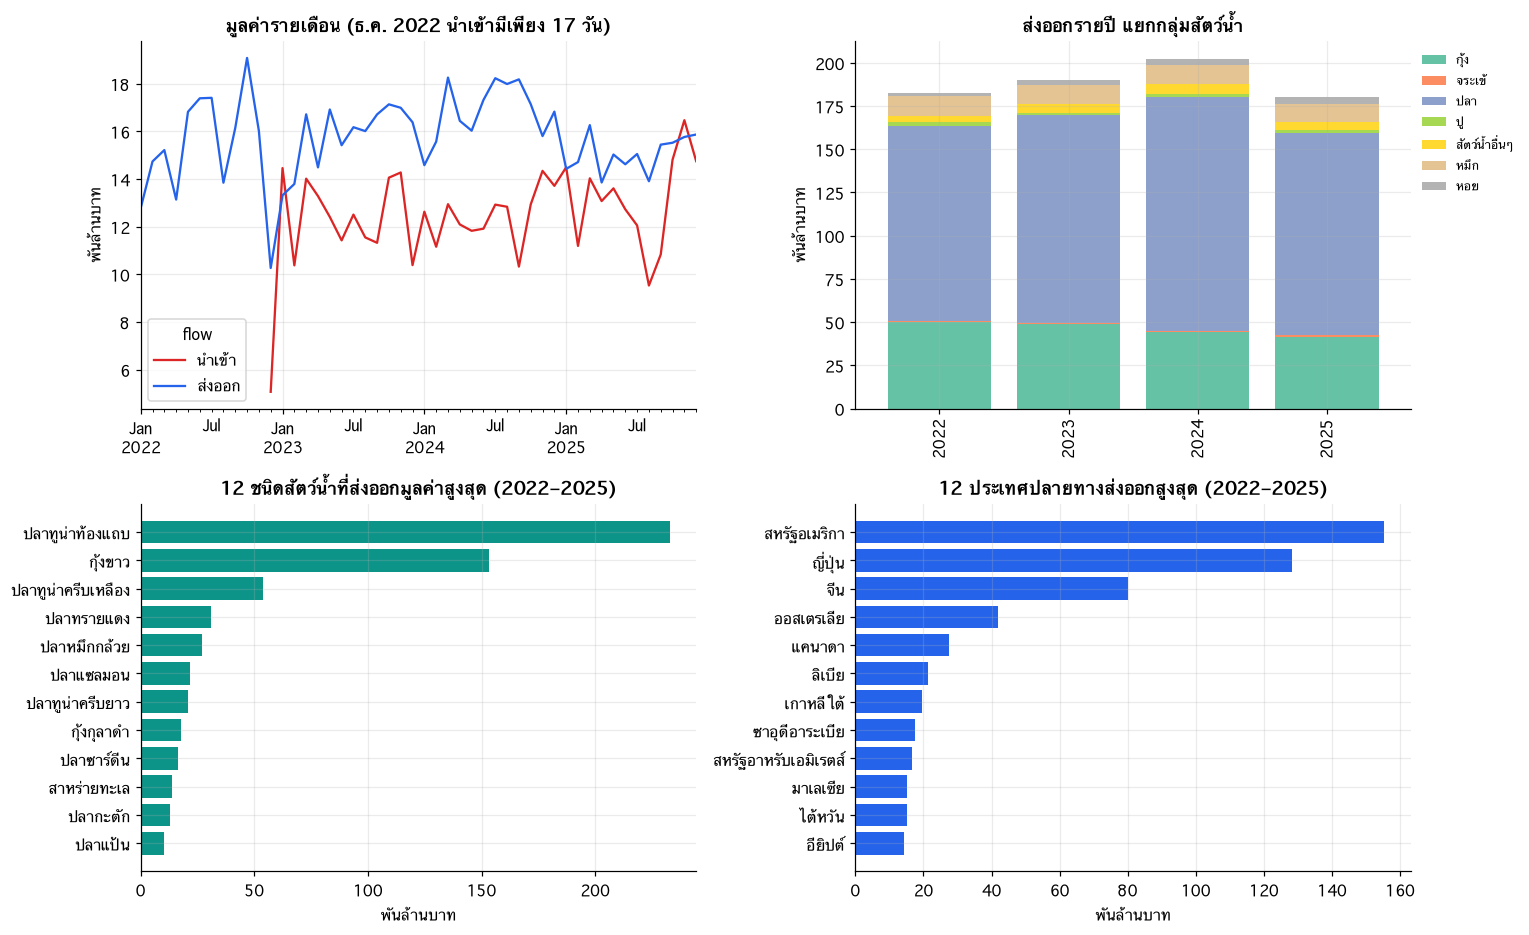

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8.6))
mm = dd.groupby([dd.date.dt.to_period("M").dt.to_timestamp(), "flow"]).value_thb.sum().unstack() / 1e9
mm.plot(ax=ax[0, 0], color=[C["red"], C["blue"]]); ax[0, 0].set(title="มูลค่ารายเดือน (ธ.ค. 2022 นำเข้ามีเพียง 17 วัน)", ylabel="พันล้านบาท", xlabel="")
g = dx.groupby(["year", "group"]).value_thb.sum().unstack() / 1e9
g.plot.bar(stacked=True, ax=ax[0, 1], colormap="Set2", width=.8); ax[0, 1].set(title="ส่งออกรายปี แยกกลุ่มสัตว์น้ำ", ylabel="พันล้านบาท", xlabel=""); ax[0, 1].legend(fontsize=8, frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
sp = dx.groupby("name_th").value_thb.sum().sort_values(ascending=False).head(12) / 1e9
ax[1, 0].barh(sp.index[::-1], sp.values[::-1], color=C["teal"]); ax[1, 0].set(title="12 ชนิดสัตว์น้ำที่ส่งออกมูลค่าสูงสุด (2022–2025)", xlabel="พันล้านบาท")
ct = dx.groupby("country_th").value_thb.sum().sort_values(ascending=False).head(12) / 1e9
ax[1, 1].barh(ct.index[::-1], ct.values[::-1], color=C["blue"]); ax[1, 1].set(title="12 ประเทศปลายทางส่งออกสูงสุด (2022–2025)", xlabel="พันล้านบาท")
plt.tight_layout(); plt.show()

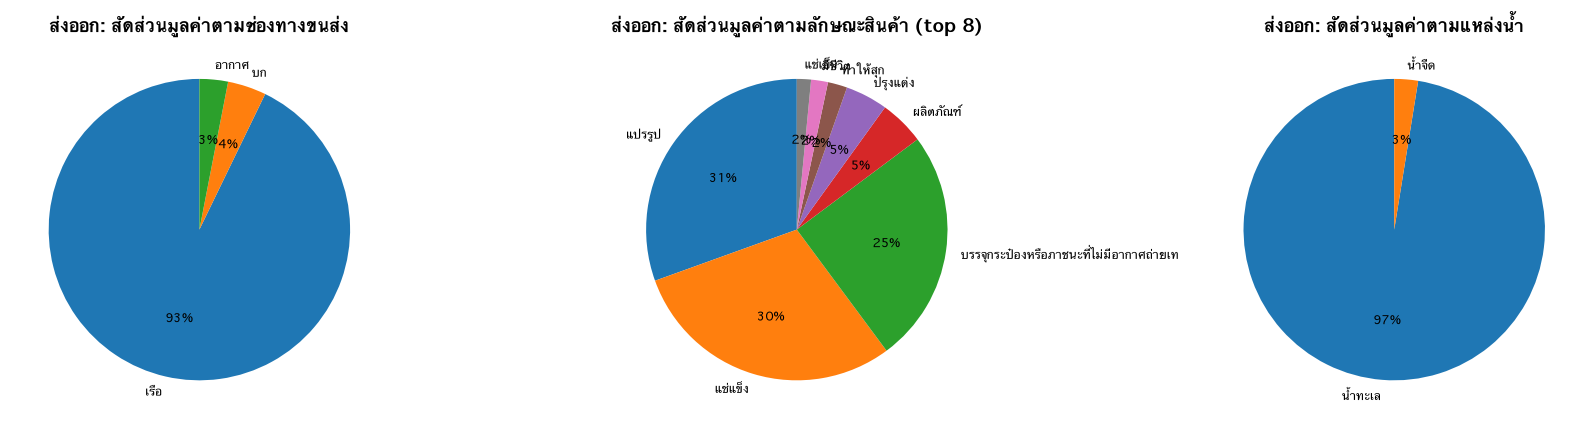

แถวมูลค่า = 0: 206 | มูลค่าว่าง: 88 | ประเทศที่ map ISO2 ไม่ได้: 1 แถว → ['ทะเลหลวง']


In [21]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col, t_ in zip(ax, ["transport", "form", "water"], ["ช่องทางขนส่ง", "ลักษณะสินค้า (top 8)", "แหล่งน้ำ"]):
    s = dx.groupby(col).value_thb.sum().sort_values(ascending=False).head(8)
    a.pie(s.values, labels=s.index, autopct="%1.0f%%", startangle=90, textprops={"fontsize": 8}); a.set(title=f"ส่งออก: สัดส่วนมูลค่าตาม{t_}"); a.grid(False)
plt.tight_layout(); plt.show()
print("แถวมูลค่า = 0:", int((dx.value_thb == 0).sum()), "| มูลค่าว่าง:", int(dx.value_thb.isna().sum()), "| ประเทศที่ map ISO2 ไม่ได้:", int(dx.country_iso2.isna().sum()), "แถว →", dx[dx.country_iso2.isna()].country_th.unique().tolist())

### 📝 อ่านผล: ข้อมูลรายวันกรมประมง (ระดับสายพันธุ์)

**ขนาด:** **2,254,417 แถว** (ส่งออก 1,413,014 / นำเข้า 841,403) ครอบคลุมทุกวันของปี 2022–2025 ฝั่งส่งออก (1,461 วันไม่ซ้ำ) ส่วนนำเข้าปี 2022 มีแค่ **17 วัน (15–31 ธ.ค.)**

**มูลค่ารายปี (พันล้านบาท)**
| | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|
| ส่งออก | 182.85 | 190.07 | **202.39** | 180.47 (−10.8% จากปี 2024) |
| นำเข้า | (17 วัน) | 150.08 | 149.65 | 157.58 |

- ส่งออกพุ่งสูงสุดปี 2024 แล้วลดลงปี 2025 ในหน่วยบาท (ส่วนหนึ่งเพราะค่าเงิน: บาทแข็งขึ้นช่วงปี 2025 ตามกราฟอัตราแลกเปลี่ยนส่วน 2.7)
- **ปลาคือกลุ่มใหญ่ที่สุด** กุ้งรองลงมา (ราว 50 → ราว 42 พันล้านบาท/ปี จากปี 2022 ถึง 2025 ตามกราฟ) ตามด้วยหมึก สัตว์น้ำอื่น ๆ
- **สายพันธุ์มูลค่าสูงสุด 3 อันดับ (รวม 2022–2025):** ปลาทูน่าท้องแถบ (ราว 233 พันล้านบาท) กุ้งขาว (ราว 153) ปลาทูน่าครีบเหลือง (ราว 53) สะท้อนว่าธุรกิจ **ทูน่ากระป๋อง** เป็นแกนหลัก สอดคล้องกับกลุ่ม 1604 ที่ครอง 59% ใน Comtrade
- **ประเทศปลายทาง:** สหรัฐฯ (ราว 156) ญี่ปุ่น (ราว 128) จีน (ราว 80) ออสเตรเลีย (ราว 42) แคนาดา (ราว 27) ลิเบีย (ราว 21) เกาหลีใต้ ซาอุฯ UAE มาเลเซีย ไต้หวัน อียิปต์ — เรียงคล้ายกับ Comtrade
- **ช่องทางขนส่ง: เรือ 93%** อากาศ 3% ทางบก 4% · **ลักษณะสินค้า:** แปรรูป 31% แช่แข็ง 30% กระป๋อง/ภาชนะปิดสนิท 25% · **น้ำทะเล 97%** น้ำจืด 3%

**คุณภาพข้อมูล**
- **แถวซ้ำทั้งแถว** (ทุกคอลัมน์ที่โหลดเหมือนกัน) พบมาก: ส่งออก 6.3–8.0% ของแถวต่อปี, นำเข้า 3.8–4.8% (ตารางนับรวมทุกสำเนา) **สำเนาส่วนเกิน 59,393 แถว (ส่งออก) และ 20,061 แถว (นำเข้า)** — ยังไม่ทราบว่าเป็นข้อมูลซ้ำจริงหรือรายการส่งของจริงที่ค่าเท่ากัน เพราะไม่มีเลขที่เอกสาร ต้องตัดสินใจในขั้นเตรียมข้อมูล
- มูลค่าว่าง 88 แถว (ทั้งหมดอยู่ใน ปี 2022 ส่งออก) มูลค่า = 0 จำนวน 206 แถว และประเทศที่ map ISO2 ไม่ได้ 1 แถว ("ทะเลหลวง" ไม่ใช่ประเทศ)

**ข้อจำกัด:** ไม่มีรหัส HS จึงเชื่อมกับ Comtrade ตรง ๆ ไม่ได้ ใช้เสริมระดับสายพันธุ์ ปีเดียวที่นำเข้า–ส่งออกครบคือ 2023–2025

## 2.5 ใบรับรองสุขภาพสัตว์น้ำเพื่อการส่งออก (ตัวชี้นำที่เป็นไปได้)

จำนวนใบรับรองรายเดือน × ประเทศปลายทาง ที่ออกโดยกรมประมง สมมติฐาน: ใบรับรองต้องออกก่อนส่งสินค้า จึงอาจเป็นสัญญาณล่วงหน้าของยอดส่งออก

In [22]:
parts = []
for f in sorted((DATA / "trade").glob("dof_health_cert_by_country_*.csv")):
    d = rd(f).rename(columns={"จำนวน": "count", "ปริมาณ": "count"}); d["file"] = f.name; parts.append(d)
hc = pd.concat(parts, ignore_index=True)
print("ขนาด:", hc.shape); display(hc.head(8))
print("คอลัมน์ในแต่ละไฟล์ (ชื่อและลำดับไม่ตรงกันทุกไฟล์):")
for f, g in hc.groupby("file"): print(" ", f, "->", [c for c in rd(DATA / "trade" / f, nrows=1).columns])

ขนาด: (612, 6)


,ลำดับ,รายชื่อประเทศ,ปี,เดือน,count,file
0,1,AUSTRALIA_[AU],2564,ต.ค.,0,dof_health_cert_by_country_2564.csv
1,2,CANADA_[CA],2564,ต.ค.,0,dof_health_cert_by_country_2564.csv
2,3,CHINA_[CN],2564,ต.ค.,46,dof_health_cert_by_country_2564.csv
3,4,INDIA_[IN],2564,ต.ค.,25,dof_health_cert_by_country_2564.csv
4,5,JAPAN_[JP],2564,ต.ค.,60,dof_health_cert_by_country_2564.csv
5,6,"KOREA, REPUBLIC OF (SOUTH)_[KR]",2564,ต.ค.,127,dof_health_cert_by_country_2564.csv
6,7,MALAYSIA_[MY],2564,ต.ค.,43,dof_health_cert_by_country_2564.csv
7,8,MYANMAR_[MM],2564,ต.ค.,0,dof_health_cert_by_country_2564.csv


คอลัมน์ในแต่ละไฟล์ (ชื่อและลำดับไม่ตรงกันทุกไฟล์):
  dof_health_cert_by_country_2564.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'ปี', 'เดือน', 'จำนวน']
  dof_health_cert_by_country_2565.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'ปี', 'เดือน', 'จำนวน']
  dof_health_cert_by_country_2566.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'เดือน', 'ปริมาณ', 'ปี']
  dof_health_cert_by_country_2567.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'เดือน', 'ปริมาณ', 'ปี']
  dof_health_cert_by_country_2568.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'เดือน', 'ปริมาณ', 'ปี']


ช่วงเวลา Oct 2021 – Dec 2025 | เดือนที่มีข้อมูล 36 จาก 51 เดือน
เดือนที่ไม่มีข้อมูลเลย: ['Oct 2022', 'Nov 2022', 'Dec 2022', 'Jan 2023', 'Feb 2023', 'Mar 2023', 'Apr 2023', 'May 2023', 'Jun 2023', 'Jul 2023', 'Aug 2023', 'Sep 2023', 'Jun 2024', 'Jul 2024', 'Aug 2024']
แถวที่ (ประเทศ, เดือน) ซ้ำกัน:


,รายชื่อประเทศ,เดือน,ปี,count
387,GERMANY_[DE],ม.ค.,2568,0
406,GERMANY_[DE],ม.ค.,2568,19


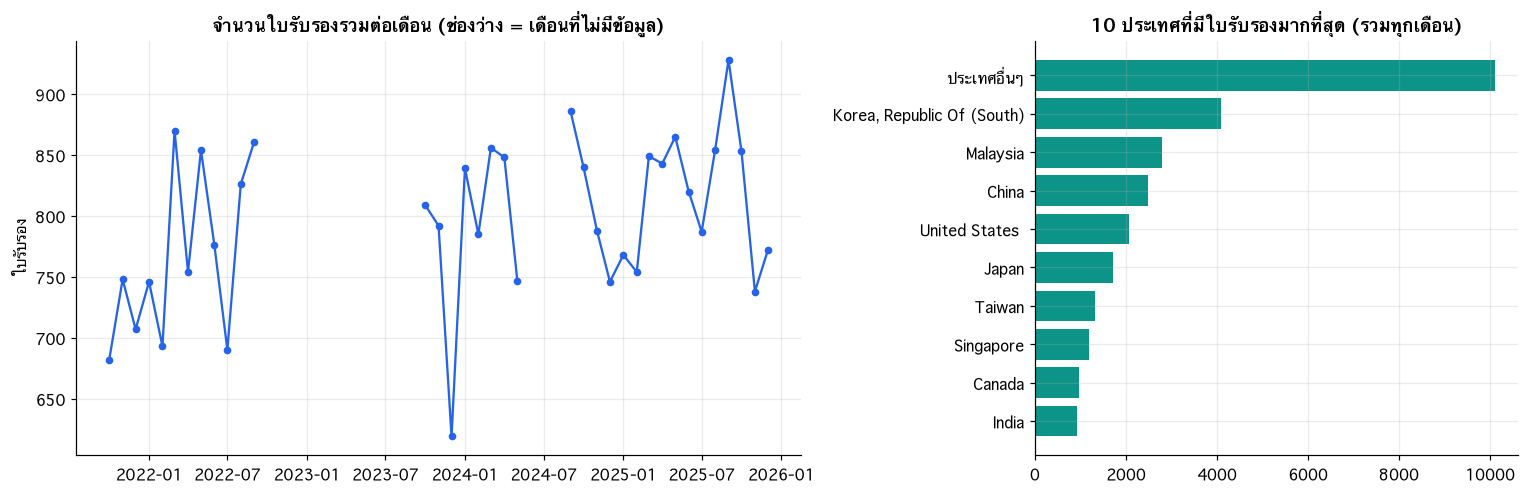

In [23]:
MON = {m: i for i, m in enumerate("ม.ค. ก.พ. มี.ค. เม.ย. พ.ค. มิ.ย. ก.ค. ส.ค. ก.ย. ต.ค. พ.ย. ธ.ค.".split(), 1)}
hc["m"] = hc["เดือน"].map(MON); hc["y"] = hc["ปี"].astype(int) - 543
hc["iso2"] = hc["รายชื่อประเทศ"].str.extract(r"_\[([A-Z]{2})\]$")[0]
hc["date"] = pd.to_datetime(dict(year=hc.y, month=hc.m, day=1))
print(f"ช่วงเวลา {hc.date.min():%b %Y} – {hc.date.max():%b %Y} | เดือนที่มีข้อมูล {hc.date.nunique()} จาก {(hc.date.max().year - hc.date.min().year) * 12 + hc.date.max().month - hc.date.min().month + 1} เดือน")
full = pd.date_range(hc.date.min(), hc.date.max(), freq="MS")
missing = [d for d in full if d not in set(hc.date)]
print("เดือนที่ไม่มีข้อมูลเลย:", [f"{d:%b %Y}" for d in missing])
dup = hc[hc.duplicated(["date", "รายชื่อประเทศ"], keep=False)][["รายชื่อประเทศ", "เดือน", "ปี", "count"]]
print("แถวที่ (ประเทศ, เดือน) ซ้ำกัน:"); display(dup)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
tot = hc.groupby("date")["count"].apply(lambda s: pd.to_numeric(s).sum()).reindex(full)
ax[0].plot(tot.index, tot.values, marker="o", ms=4, color=C["blue"]); ax[0].set(title="จำนวนใบรับรองรวมต่อเดือน (ช่องว่าง = เดือนที่ไม่มีข้อมูล)", ylabel="ใบรับรอง")
c = hc.assign(v=pd.to_numeric(hc["count"])).groupby("รายชื่อประเทศ").v.sum().sort_values(ascending=False).head(10)
ax[1].barh([i.split("_[")[0].title() for i in c.index][::-1], c.values[::-1], color=C["teal"]); ax[1].set(title="10 ประเทศที่มีใบรับรองมากที่สุด (รวมทุกเดือน)")
plt.tight_layout(); plt.show()

แถว (ประเทศ × เดือน) ที่จับคู่ได้: 330 | Spearman เดือนเดียวกัน = 0.44 | ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 = 0.43
ภายในประเทศเดียวกัน (ตัดผลขนาดตลาด): เดือนเดียวกัน = 0.02 | ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 = -0.14 | จำนวนประเทศ = 19


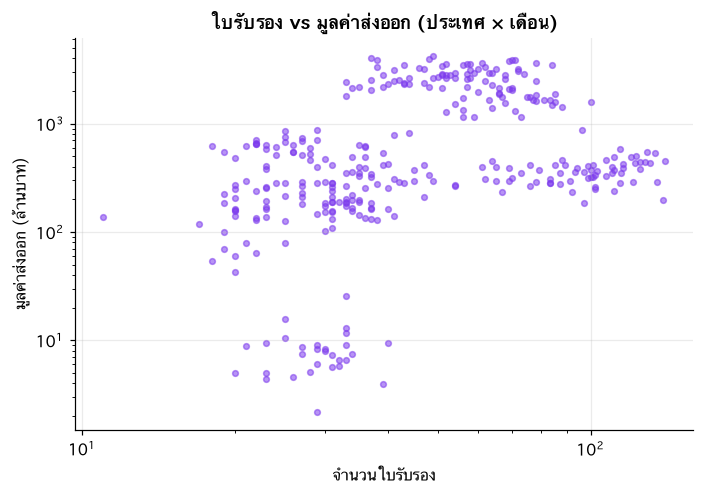

In [24]:
# เป็นตัวชี้นำของยอดส่งออกจริงหรือไม่? เทียบกับยอดส่งออกรายวันของกรมประมง (บาท) ระดับ ประเทศ × เดือน
hcm = hc.assign(v=pd.to_numeric(hc["count"])).groupby(["iso2", "date"], as_index=False).v.sum().dropna()
exm = dx.groupby(["country_iso2", dx.date.dt.to_period("M").dt.to_timestamp()], as_index=False).value_thb.sum().rename(columns={"country_iso2": "iso2", "date": "date"})
j = hcm.merge(exm, on=["iso2", "date"])
j = j[(j.v > 0) & (j.value_thb > 0)]
rho0 = j[["v", "value_thb"]].corr(method="spearman").iloc[0, 1]
# lead: ใบรับรองเดือน t เทียบกับยอดส่งออกเดือน t+1
lead = hcm.assign(date=hcm.date + pd.offsets.MonthBegin(-1)).merge(exm, on=["iso2", "date"]); lead = lead[(lead.v > 0) & (lead.value_thb > 0)]
rho1 = lead[["v", "value_thb"]].corr(method="spearman").iloc[0, 1]
print(f"แถว (ประเทศ × เดือน) ที่จับคู่ได้: {len(j)} | Spearman เดือนเดียวกัน = {rho0:.2f} | ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 = {rho1:.2f}")

# แยกผลของ "ขนาดตลาดต่างกัน" ออก: วัดความสัมพันธ์ *ภายในประเทศเดียวกัน* (ลบค่าเฉลี่ยของแต่ละประเทศออกก่อน)
def within(df):
    d = df.assign(a=np.log(df.v), b=np.log(df.value_thb)); d[["a", "b"]] -= d.groupby("iso2")[["a", "b"]].transform("mean")
    return d[["a", "b"]].corr(method="spearman").iloc[0, 1]
print(f"ภายในประเทศเดียวกัน (ตัดผลขนาดตลาด): เดือนเดียวกัน = {within(j):.2f} | ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 = {within(lead):.2f} | จำนวนประเทศ = {j.iso2.nunique()}")
fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.scatter(j.v, j.value_thb / 1e6, s=14, alpha=.55, color=C["purple"]); ax.set_xscale("log"); ax.set_yscale("log")
ax.set(title="ใบรับรอง vs มูลค่าส่งออก (ประเทศ × เดือน)", xlabel="จำนวนใบรับรอง", ylabel="มูลค่าส่งออก (ล้านบาท)")
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ใบรับรองสุขภาพสัตว์น้ำ

**ข้อมูลที่มี:** 612 แถว จาก 5 ไฟล์ซึ่งชื่อและลำดับคอลัมน์ไม่เหมือนกัน (`จำนวน` ในปี 2564–2565 แต่ `ปริมาณ` ในปี 2566–2568) ช่วง ต.ค. 2021 – ธ.ค. 2025 **มีข้อมูล 36 จาก 51 เดือน ขาด 15 เดือน** (ต.ค. 2022 – ก.ย. 2023 ต่อเนื่อง 12 เดือน และ มิ.ย.–ส.ค. 2024) และมีคู่ (ประเทศ, เดือน) ซ้ำ 1 คู่ (เยอรมนี ม.ค. 2025: 0 และ 19)

**ภาพที่เห็น**
- จำนวนใบรับรองรวมอยู่ที่ราว **620–930 ใบ/เดือน** ค่อนข้างนิ่ง ไม่มีแนวโน้มชัดเจน
- **หมวด "ประเทศอื่น ๆ" ใหญ่ที่สุด (ราว 10,000 ใบ)** แปลว่าข้อมูลส่วนใหญ่ไม่ระบุประเทศ ส่วนประเทศที่ระบุ: เกาหลีใต้ (ราว 4,100) มาเลเซีย (ราว 2,800) จีน (ราว 2,500) สหรัฐฯ (ราว 2,050) ญี่ปุ่น (ราว 1,700)
- **ประเทศที่มีใบรับรองมาก ไม่ตรงกับประเทศที่ส่งออกมูลค่ามาก** (เกาหลีใต้และมาเลเซียมีใบรับรองมากกว่าสหรัฐฯ และญี่ปุ่น) เป็นไปได้ว่าใบรับรองเกี่ยวกับสัตว์น้ำมีชีวิต/สด มากกว่าสินค้ากระป๋อง/แปรรูปที่มีมูลค่าส่งออกสูง (ข้อสังเกตจากข้อมูลเท่านั้น ยังไม่ยืนยัน)

**ทดสอบว่าเป็นตัวชี้นำยอดส่งออกหรือไม่**
| การวัด | Spearman |
|---|---|
| รวมทุกประเทศ เดือนเดียวกัน (330 จุด) | 0.44 |
| รวมทุกประเทศ ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 | 0.43 |
| **ภายในประเทศเดียวกัน** (ตัดผลขนาดตลาด) เดือนเดียวกัน | **0.02** |
| **ภายในประเทศเดียวกัน** ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 | **−0.14** |

- ความสัมพันธ์ 0.44 **เป็นผลจากขนาดตลาดที่ต่างกัน** (ประเทศใหญ่มีทั้งใบรับรองและยอดส่งออกมาก — ในกราฟกระจายเห็นเป็นแถบแนวนอนแยกตามกลุ่มประเทศ) พอวัดภายในประเทศเดียวกันเหลือเกือบ 0 และไม่ใช่การนำล่วงหน้า (ค่า lead ไม่ดีกว่าเดือนเดียวกัน)
- **สรุป: ในข้อมูลนี้ ใบรับรองสุขภาพไม่ใช่ตัวชี้นำยอดส่งออกที่ใช้งานได้** ครอบคลุมเวลาก็ขาดหลายช่วง → จัดลำดับความสำคัญต่ำ

## 2.6 ฝั่งผลผลิต (supply side)

ข้อมูลผลผลิตสัตว์น้ำของกรมประมง ทั้งการจับและการเพาะเลี้ยง ใช้เป็นบริบทและ feature เสริม

ผลผลิตรวมระดับประเทศรายปี (พันตัน)


,year_be,total,marine_capture,freshwater_capture,coastal_aquaculture,freshwater_aquaculture,year
21,2562,"2,491.00","1,410.70",116.50,536.50,427.30,2019
22,2563,"2,600.20","1,472.00",116.80,556.80,454.60,2020
23,2564,"2,402.90","1,299.50",112.60,540.10,450.70,2021
24,2565,"2,386.70","1,279.80",105.70,534.20,467.00,2022
25,2566,"2,467.30","1,351.50",114.60,541.20,460.00,2023
26,2567,"2,541.40","1,434.90",107.90,530.20,468.40,2024


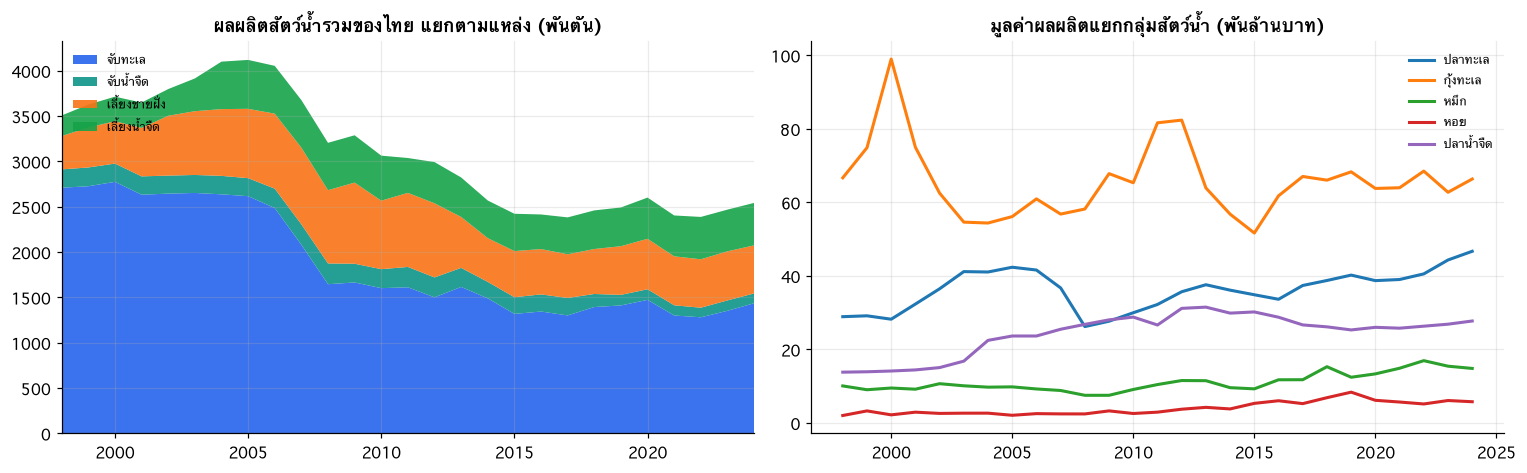

In [25]:
ps = rd(CL / "supply_side/production_by_source_quantity.csv")
print("ผลผลิตรวมระดับประเทศรายปี (พันตัน)"); display(ps.tail(6))
src = {"marine_capture": "จับทะเล", "freshwater_capture": "จับน้ำจืด", "coastal_aquaculture": "เลี้ยงชายฝั่ง", "freshwater_aquaculture": "เลี้ยงน้ำจืด"}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
ax[0].stackplot(ps.year, [ps[k] for k in src], labels=src.values(), colors=[C["blue"], C["teal"], C["orange"], C["green"]], alpha=.9)
ax[0].set(title="ผลผลิตสัตว์น้ำรวมของไทย แยกตามแหล่ง (พันตัน)", xlim=(ps.year.min(), ps.year.max())); ax[0].legend(loc="upper left", frameon=False, fontsize=8)
pv = rd(CL / "supply_side/production_by_species_group_value.csv")
cols = ["marine_fish", "marine_shrimp", "marine_squid", "marine_shellfish", "freshwater_fish"]
nm = {"marine_fish": "ปลาทะเล", "marine_shrimp": "กุ้งทะเล", "marine_squid": "หมึก", "marine_shellfish": "หอย", "freshwater_fish": "ปลาน้ำจืด"}
for c_ in cols: ax[1].plot(pv.year, pv[c_] / 1000, label=nm[c_], lw=2)
ax[1].set(title="มูลค่าผลผลิตแยกกลุ่มสัตว์น้ำ (พันล้านบาท)"); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

ผลผลิตกุ้งรายเดือน × จังหวัด × ชนิด: (1596, 10)


,date,year,year_be,month,province,region,species,quantity,year_inferred,source_file
0,2024-01-01,2024,2567,1,กระบี่,ภาคใต้ฝั่งอันดามัน,กุ้งกุลาดำ,507.74,False,dof_shrimp_production_monthly_2567.csv
1,2024-01-01,2024,2567,1,กระบี่,ภาคใต้ฝั่งอันดามัน,กุ้งขาว,445.12,False,dof_shrimp_production_monthly_2567.csv
2,2024-01-01,2024,2567,1,กรุงเทพมหานคร,ภาคกลาง,กุ้งกุลาดำ,0.00,False,dof_shrimp_production_monthly_2567.csv
3,2024-01-01,2024,2567,1,กรุงเทพมหานคร,ภาคกลาง,กุ้งขาว,2.60,False,dof_shrimp_production_monthly_2567.csv
4,2024-01-01,2024,2567,1,กาญจนบุรี,ภาคกลาง,กุ้งกุลาดำ,0.00,False,dof_shrimp_production_monthly_2567.csv
5,2024-01-01,2024,2567,1,กาญจนบุรี,ภาคกลาง,กุ้งขาว,0.00,False,dof_shrimp_production_monthly_2567.csv


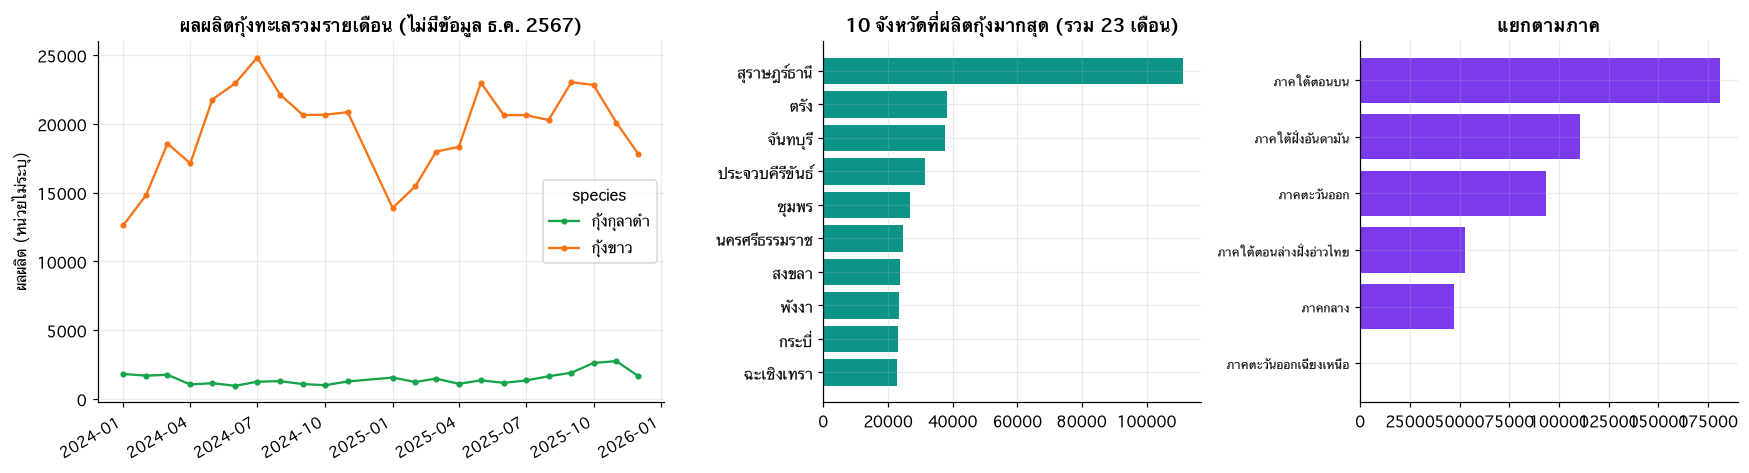

จำนวนเดือนที่มีข้อมูล: 23 | ไฟล์ต้นฉบับชื่อ 'ปี 2569' ถูกตีความเป็นปี 2568 (year_inferred): 826 แถว


In [26]:
sh = rd(CL / "supply_side/shrimp_production_monthly_province.csv", parse_dates=["date"])
print("ผลผลิตกุ้งรายเดือน × จังหวัด × ชนิด:", sh.shape); display(sh.head(6))
mt = sh.groupby(["date", "species"]).quantity.sum().unstack()
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={"width_ratios": [1.5, 1, 1]})
mt.plot(ax=ax[0], marker="o", ms=3, color=[C["green"], C["orange"]]); ax[0].set(title="ผลผลิตกุ้งทะเลรวมรายเดือน (ไม่มีข้อมูล ธ.ค. 2567)", ylabel="ผลผลิต (หน่วยไม่ระบุ)", xlabel="")
p = sh.groupby("province").quantity.sum().sort_values(ascending=False).head(10)
ax[1].barh(p.index[::-1], p.values[::-1], color=C["teal"]); ax[1].set(title="10 จังหวัดที่ผลิตกุ้งมากสุด (รวม 23 เดือน)")
rg = sh.groupby("region").quantity.sum().sort_values()
ax[2].barh(rg.index, rg.values, color=C["purple"]); ax[2].set(title="แยกตามภาค"); ax[2].tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()
print("จำนวนเดือนที่มีข้อมูล:", sh.date.nunique(), "| ไฟล์ต้นฉบับชื่อ 'ปี 2569' ถูกตีความเป็นปี 2568 (year_inferred):", int(sh.year_inferred.sum()), "แถว")

การจับสัตว์น้ำทะเลรายเดือน: (45636, 11)


,year,year_be,month,fishing_type,gear,vessel_size,fishing_area,species_th,quantity,value,date
0,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาทูแขก,47.00,"1,431.00",2022-01-01
1,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาสีกุนตาโต,15.00,704.00,2022-01-01
2,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาน้ำดอกไม้,55.00,"3,306.00",2022-01-01
3,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาทรายแดง,43.00,"1,743.00",2022-01-01
4,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาปากคม,57.00,"1,775.00",2022-01-01
5,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาตาโต,4.00,172.00,2022-01-01


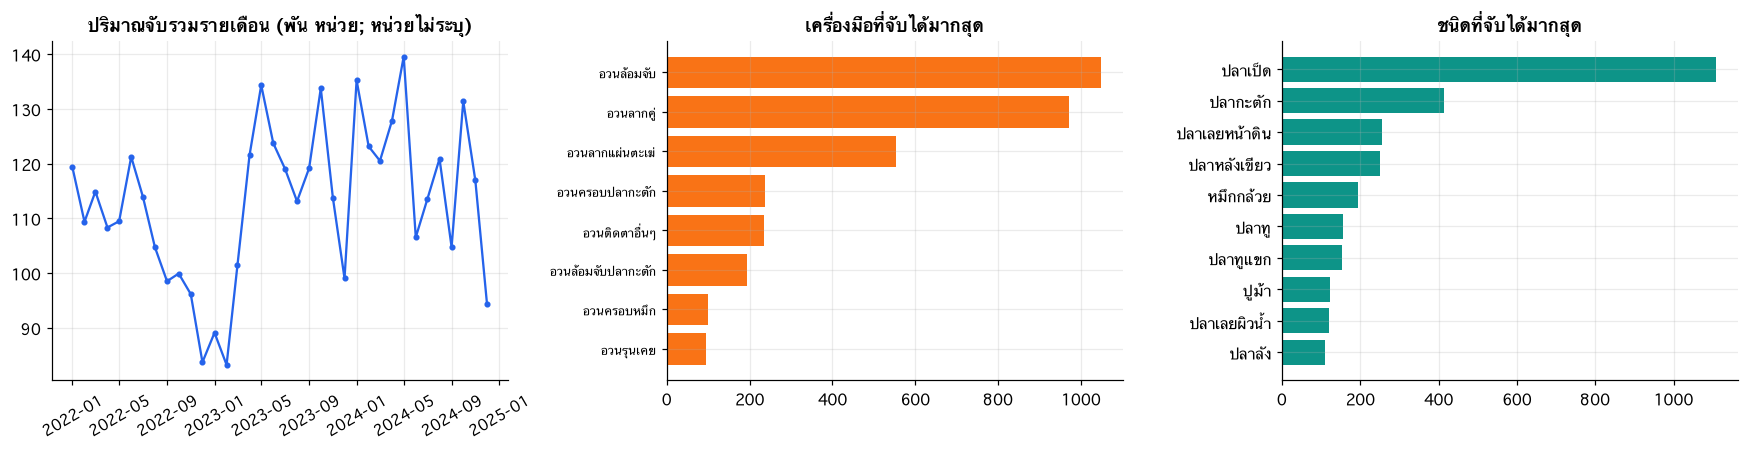

การเพาะเลี้ยง (รวม 5 ประเภท): (16791, 11)


,,จังหวัด,ฟาร์ม,ปริมาณ
category,year,,,
brackish_fish,2024,31,6946,"60,271.00"
freshwater,2024,77,523255,"468,374.00"
marine_crab,2024,20,4827,"3,700.28"
marine_shellfish,2024,19,5381,"76,459.43"
marine_shrimp,2024,35,27385,"389,841.00"


In [27]:
mc = rd(CL / "supply_side/marine_catch_monthly.csv")
mc["date"] = pd.to_datetime(dict(year=mc.year, month=mc.month, day=1))
print("การจับสัตว์น้ำทะเลรายเดือน:", mc.shape); display(mc.head(6))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
mm = mc.groupby("date")[["quantity", "value"]].sum()
ax[0].plot(mm.index, mm.quantity / 1e3, marker="o", ms=3, color=C["blue"]); ax[0].set(title="ปริมาณจับรวมรายเดือน (พัน หน่วย; หน่วยไม่ระบุ)", xlabel=""); ax[0].tick_params(axis="x", rotation=30)
g = mc.groupby("gear").quantity.sum().sort_values(ascending=False).head(8)
ax[1].barh(g.index[::-1], g.values[::-1] / 1e3, color=C["orange"]); ax[1].set(title="เครื่องมือที่จับได้มากสุด"); ax[1].tick_params(axis="y", labelsize=8)
s = mc.groupby("species_th").quantity.sum().sort_values(ascending=False).head(10)
ax[2].barh(s.index[::-1], s.values[::-1] / 1e3, color=C["teal"]); ax[2].set(title="ชนิดที่จับได้มากสุด")
plt.tight_layout(); plt.show()
aq = rd(CL / "supply_side/aquaculture_yearly.csv")
print("การเพาะเลี้ยง (รวม 5 ประเภท):", aq.shape); display(aq.groupby(["category", "year"]).agg(จังหวัด=("province", "nunique"), ฟาร์ม=("farms", "sum"), ปริมาณ=("quantity", "sum")).groupby("category").tail(1))

### 📝 อ่านผล: ฝั่งผลผลิต (supply)

**ผลผลิตรวมของไทย (กราฟซ้าย)**
- ผลผลิตสัตว์น้ำรวมลดลงมากช่วงราว **ค.ศ. 2005–2015** (จากประมาณ 4 ล้านตัน เหลือประมาณ 2.4 ล้านตัน — อ่านจากกราฟ แกนเป็น ค.ศ.) โดยการจับทะเลลดลงประมาณครึ่งหนึ่ง แล้ว **ทรงตัวตั้งแต่ ค.ศ. 2015**: ปี 2562–2567 อยู่ที่ **2.39–2.60 ล้านตัน** (ปี 2567 = 2.54 ล้านตัน แบ่งเป็นจับทะเล 1.43, เลี้ยงชายฝั่ง 0.53, เลี้ยงน้ำจืด 0.47, จับน้ำจืด 0.11)
- ช่วงที่ผลผลิตลดลงตรงกับช่วงที่ยอดส่งออกใน Comtrade ลดระดับ (ส่วน 2.2) แต่ยังไม่ได้ทดสอบว่าสองอย่างสัมพันธ์กันจริงหรือไม่
- มูลค่ากุ้งทะเลอยู่ราว 62–69 พันล้านบาทต่อปีตั้งแต่ ค.ศ. 2016 (เคยพุ่งสูงราว 99 พันล้านใน ค.ศ. 2000 และราว 82 พันล้านใน ค.ศ. 2012 ตามกราฟ)

**ผลผลิตกุ้งรายเดือน × จังหวัด (ข้อมูลใหม่ 23 เดือน)**
- **กุ้งขาวคือตัวหลัก** ราว 12,000–25,000 ต่อเดือน (หน่วยไม่ระบุ) ส่วนกุ้งกุลาดำราว 1,000–2,800 ต่อเดือน
- **ฤดูกาลเห็นชัด:** ต่ำสุดที่ ม.ค. (ราว 12,600 ปี 2024 / 13,900 ปี 2025) แล้วเพิ่มขึ้นกลางปีและปลายปี (สูงสุดราว 24,800 ใน ก.ค. 2024; ปี 2025 สูงช่วง พ.ค. และ ก.ย.–พ.ย.) เป็นรูปแบบที่ชัดกว่าข้อมูลส่งออกมาก
- **สุราษฎร์ธานีผลิตมากที่สุดอย่างโดดเด่น** (ราว 111,000 รวม 23 เดือน) ตามด้วยตรังและจันทบุรี (ราว 37,000–38,000) ภาคใต้ตอนบนเป็นภาคที่ผลผลิตสูงสุด
- ข้อควรระวัง: ไฟล์ที่ catalog ตั้งชื่อ "ปี 2569" ถูกตีความว่าเป็นปี 2568 (อนุมาน, ไม่ได้ยืนยัน) และไม่มีเดือน ธ.ค. 2024

**การจับสัตว์น้ำทะเลรายเดือน (36 เดือน, 2022–2024)**
- ปริมาณรวม 83,000–140,000 หน่วย/เดือน (หน่วยไม่ระบุ) แกว่งแต่ยังไม่เห็นรูปแบบซ้ำรายปีที่ชัด
- **เครื่องมือที่จับได้มาก:** อวนล้อมจับ (ราว 1,050 พันหน่วย) อวนลากคู่ (ราว 970) อวนลากแผ่นตะเฆ่ (ราว 550) · **ชนิดที่จับได้มากสุด: ปลาเป็ด** (ราว 1,100 พันหน่วย) มากกว่าลำดับ 2 (ปลากะตัก ราว 410) กว่าเท่าตัว (ปลาเป็ดเป็นปลาไม่ได้ขายเป็นอาหารมนุษย์โดยตรง ความเชื่อมโยงกับสินค้าส่งออกจึงอ้อม)

**การเพาะเลี้ยง (ปี 2567):** กุ้งทะเล 35 จังหวัด 27,385 ฟาร์ม ผลผลิต 389,841 · น้ำจืด 77 จังหวัด 523,255 ฟาร์ม ผลผลิต 468,374

**ข้อสรุป:** ข้อมูลกุ้งรายเดือนมีฤดูกาลชัดแต่สั้น (23 เดือน) ใช้เป็นข้อมูลประกอบหรือ feature ฝั่ง supply ได้ ไม่พอเป็นเป้าหมายของโมเดลพยากรณ์ผลผลิตเอง ยังไม่ได้ทดสอบความสัมพันธ์กับยอดส่งออก

## 2.7 ข้อมูลภายนอก: อัตราแลกเปลี่ยน · เศรษฐกิจรายประเทศ · สภาพอากาศ

อัตราแลกเปลี่ยน: (45275, 5)


,date,currency,per_usd,thb_per_usd,thb_per_unit
0,2020-12-31,AUD,1.30,29.93,23.10
1,2021-01-04,AUD,1.30,29.87,23.06
2,2021-01-05,AUD,1.30,29.97,23.09
3,2021-01-06,AUD,1.28,29.93,23.33
4,2021-01-07,AUD,1.29,30.02,23.28


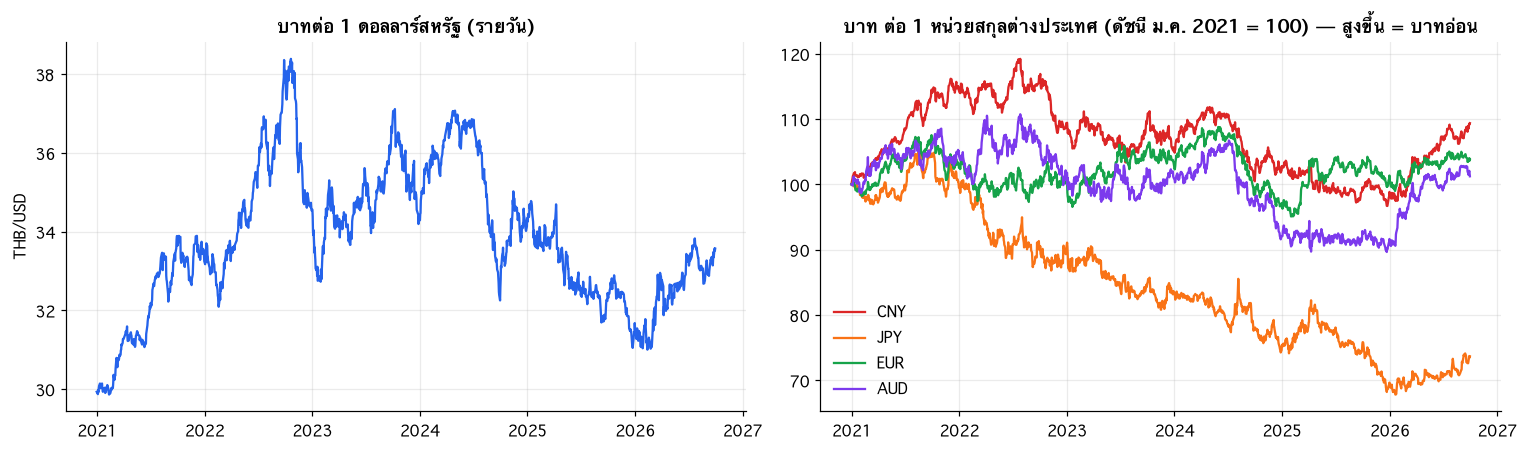

corr(การเปลี่ยนแปลงรายเดือนของ THB/USD, ของยอดส่งออกรวม Comtrade) = 0.06  (n = 63 เดือน)
สกุลเงินที่มี: ['AUD', 'BGN', 'BRL', 'CAD', 'CHF', 'CNY', 'CZK', 'DKK', 'EUR', 'GBP', 'HKD', 'HRK', 'HUF', 'IDR', 'ILS', 'INR', 'ISK', 'JPY', 'KRW', 'MXN', 'MYR', 'NOK', 'NZD', 'PHP', 'PLN', 'RON', 'RUB', 'SEK', 'SGD', 'THB', 'TRY', 'ZAR']
สกุลเงินของตลาดใหญ่ที่ *ไม่มี* ใน ECB: TWD (ไต้หวัน), VND (เวียดนาม), AED (UAE), SAR (ซาอุฯ)


In [28]:
fx = rd(E / "fx_daily_usd_base_ecb.csv", parse_dates=["date"])
print("อัตราแลกเปลี่ยน:", fx.shape); display(fx.head(5))
thb = fx[fx.currency == "THB"].set_index("date").thb_per_usd
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].plot(thb.index, thb.values, color=C["blue"]); ax[0].set(title="บาทต่อ 1 ดอลลาร์สหรัฐ (รายวัน)", ylabel="THB/USD")
for cur, col in [("CNY", C["red"]), ("JPY", C["orange"]), ("EUR", C["green"]), ("AUD", C["purple"])]:
    s = fx[fx.currency == cur].set_index("date").thb_per_unit; ax[1].plot(s.index, s / s.iloc[0] * 100, label=cur, color=col)
ax[1].set(title="บาท ต่อ 1 หน่วยสกุลต่างประเทศ (ดัชนี ม.ค. 2021 = 100) — สูงขึ้น = บาทอ่อน"); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()
tot_m = world.groupby("date").value_usd.sum()
j_fx = pd.concat([np.log(thb.resample("MS").mean()).diff(), np.log(tot_m).diff()], axis=1, keys=["fx", "export"]).dropna().loc["2021-02":]
print(f"corr(การเปลี่ยนแปลงรายเดือนของ THB/USD, ของยอดส่งออกรวม Comtrade) = {j_fx.corr().iloc[0, 1]:.2f}  (n = {len(j_fx)} เดือน)")
print("สกุลเงินที่มี:", sorted(fx.currency.unique()))
print("สกุลเงินของตลาดใหญ่ที่ *ไม่มี* ใน ECB: TWD (ไต้หวัน), VND (เวียดนาม), AED (UAE), SAR (ซาอุฯ)")

In [29]:
wb = rd(E / "worldbank_indicators_yearly.csv"); wmeta = rd(E / "worldbank_country_meta.csv")
print("World Bank:", wb.shape); display(wb[wb.iso3 == "THA"].tail(3))
cov = wb.groupby("year")[["gdp_usd", "gdp_per_capita_usd", "population", "inflation_cpi_pct", "gdp_growth_pct"]].count()
print("จำนวนประเทศที่มีค่า (ไม่ว่าง) ในแต่ละปี"); display(cov.T)
# join กับประเทศคู่ค้าใน Comtrade ได้แค่ไหน (ถ่วงน้ำหนักด้วยมูลค่าปี 2025)
v25 = part[(part.year == 2025) & part.partner_iso2.notna()].groupby("partner_iso2").value_usd.sum()
have = v25.index.isin(wb.iso2.dropna().unique())
print(f"\nประเทศคู่ค้า Comtrade ปี 2025: {len(v25)} | join กับ World Bank ได้ {have.sum()} ประเทศ ({v25[have].sum() / v25.sum() * 100:.1f}% ของมูลค่า)")
print("ที่ join ไม่ได้ (เรียงตามมูลค่า):", v25[~have].sort_values(ascending=False).head(8).div(1e6).round(1).to_dict(), "(ล้านดอลลาร์)")

World Bank: (2387, 9)


,iso2,iso3,name_en,year,gdp_usd,gdp_per_capita_usd,population,inflation_cpi_pct,gdp_growth_pct
2098,TH,THA,Thailand,2023,"517,013,369,475.12","7,210.54","71,702,435.00",1.23,2.25
2099,TH,THA,Thailand,2024,"529,385,520,941.54","7,386.64","71,668,011.00",0.40,2.95
2100,TH,THA,Thailand,2025,"577,009,981,112.02","8,056.56","71,619,863.00",-0.13,2.44


จำนวนประเทศที่มีค่า (ไม่ว่าง) ในแต่ละปี


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
gdp_usd,212,211,211,211,211,210,210,209,204,200,186
gdp_per_capita_usd,212,211,211,211,211,210,210,209,204,200,186
population,217,217,217,217,217,217,217,217,217,217,217
inflation_cpi_pct,189,189,184,183,183,178,178,178,176,174,165
gdp_growth_pct,211,210,210,211,210,210,210,209,204,200,186



ประเทศคู่ค้า Comtrade ปี 2025: 174 | join กับ World Bank ได้ 174 ประเทศ (100.0% ของมูลค่า)
ที่ join ไม่ได้ (เรียงตามมูลค่า): {} (ล้านดอลลาร์)


สภาพอากาศ: (12558, 10)


,date,province,latitude,longitude,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,month
0,2021-01-01,สมุทรสาคร,13.55,100.27,22.10,25.90,18.70,0.00,15.30,1
1,2021-01-02,สมุทรสาคร,13.55,100.27,22.40,26.60,18.90,0.00,15.80,1
2,2021-01-03,สมุทรสาคร,13.55,100.27,23.60,28.60,19.70,0.00,15.30,1
3,2021-01-04,สมุทรสาคร,13.55,100.27,24.90,29.50,21.30,0.00,14.00,1


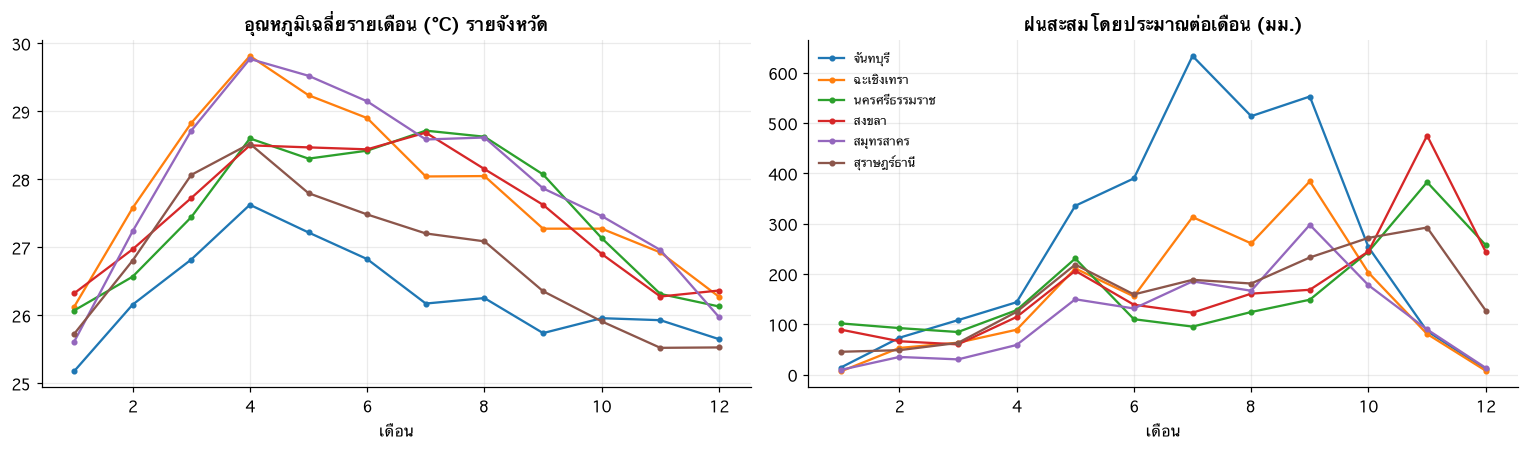

In [30]:
wx = rd(E / "weather_daily_shrimp_provinces.csv", parse_dates=["date"]); wx["month"] = wx.date.dt.month
print("สภาพอากาศ:", wx.shape); display(wx.head(4))
cl = wx.groupby(["province", "month"]).agg(temp=("temperature_2m_mean", "mean"), rain=("precipitation_sum", "sum")).reset_index()
cl["rain"] = cl.rain / wx.date.dt.year.nunique()  # ฝนรวมต่อเดือนโดยประมาณ (เฉลี่ยต่อปี)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for p_, g in cl.groupby("province"):
    ax[0].plot(g.month, g.temp, label=p_, marker="o", ms=3); ax[1].plot(g.month, g.rain, label=p_, marker="o", ms=3)
ax[0].set(title="อุณหภูมิเฉลี่ยรายเดือน (°C) รายจังหวัด", xlabel="เดือน"); ax[1].set(title="ฝนสะสมโดยประมาณต่อเดือน (มม.)", xlabel="เดือน"); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ข้อมูลภายนอก

**อัตราแลกเปลี่ยน (ECB, 32 สกุล, ธ.ค. 2020 – ก.ย. 2026)**
- บาทต่อดอลลาร์: ราว **29.9 (ม.ค. 2021) → ราว 38.4 (ปลายปี 2022, บาทอ่อนสุด) → ราว 31 (ต้นปี 2026, บาทแข็งสุด) → 33.6 (ปลาย ก.ย. 2026)**
- กราฟขวาแสดงการเคลื่อนไหวของค่าเงินตลาดปลายทางเทียบบาท (ดัชนี ม.ค. 2021 = 100): **เยนอ่อนลงมากที่สุด (ราว 70)** ขณะที่หยวน (ราว 109) และยูโร (ราว 104) เปลี่ยนไม่มาก
- ECB **ไม่มี TWD, VND, AED, SAR** ซึ่งเป็นตลาดสำคัญ (ไต้หวัน เวียดนาม สหรัฐอาหรับเอมิเรตส์ ซาอุดีอาระเบีย)
- **ค่าเงินกับยอดส่งออก:** ความสัมพันธ์ระหว่างการเปลี่ยนแปลงรายเดือนของ THB/USD กับยอดส่งออกรวมของ Comtrade (USD) ที่คำนวณในโค้ดด้านบนต่ำมาก (corr ≈ 0.06, n = 63 เดือน) จึง **ยังไม่มีหลักฐานว่าค่าเงินเป็น feature ที่ช่วยทำนายยอดส่งออกรวม** (ยังไม่ได้ทดสอบระดับประเทศ × สินค้า)

**World Bank**
- ประชากรมีครบ 217 ประเทศทุกปี แต่ **GDP ปี 2025 มีเพียง 186 ประเทศ (ขาด 31) และเงินเฟ้อ 165 ประเทศ** → ปีล่าสุดไม่ครบ ต้องใช้ค่าปีก่อนหน้าสำหรับประเทศที่ยังไม่รายงาน
- **ประเทศคู่ค้า Comtrade ปี 2025 ทั้ง 174 ประเทศที่มี ISO2 join กับ World Bank ได้ครบ** (ที่ join ไม่ได้มีแค่กลุ่ม "Other Asia, nes" 1.9% ของมูลค่า) แปลว่าใช้ GDP, ประชากร, ระดับรายได้, ภูมิภาค ประกอบการจัดกลุ่มตลาดได้

**สภาพอากาศ (6 จังหวัด)**
- อุณหภูมิเฉลี่ยรายเดือน 25–30 °C สูงสุดช่วง เม.ย. ฝนตกชุกต่างกันตามจังหวัด: จันทบุรีฝนสูงสุดช่วง ก.ค. (ราว 630 มม./เดือน) ส่วนสงขลา นครศรีธรรมราช และสุราษฎร์ธานีมีฝนช่วงปลายปี (ราว ต.ค.–พ.ย.)
- ใช้ประกอบฝั่งผลผลิตได้ แต่ไม่ผูกกับยอดส่งออกรายประเทศโดยตรง

## 2.8 ตรวจสอบข้าม: ตัวเลขจากแหล่งต่าง ๆ ตรงกันไหม

ข้อมูลส่งออกมาจาก 3 แหล่ง (Comtrade, กรมประมง `trade_hs`, กรมประมงรายวัน) ถ้านิยามเหมือนกันควรได้ยอดใกล้เคียงกัน เพราะนี่คือการตรวจ *ความน่าเชื่อถือ* ของข้อมูลหลัก แปลงบาทเป็นดอลลาร์ด้วยอัตราแลกเปลี่ยนเฉลี่ยรายเดือนจาก ECB

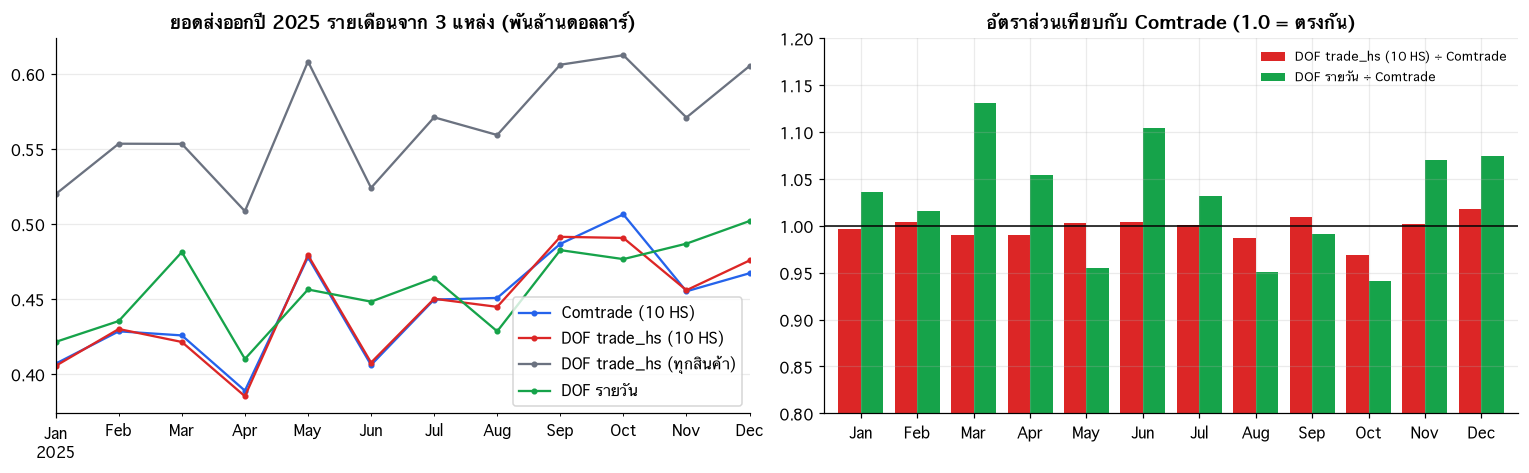

,รวมปี 2025 (พันล้านดอลลาร์),เทียบ Comtrade
Comtrade 10 HS,5.35,1.00
DOF trade_hs 10 HS,5.34,1.00
DOF trade_hs ทุกสินค้า,6.79,1.27
DOF รายวัน,5.49,1.03


ความสัมพันธ์ของอนุกรมรายเดือนปี 2025 กับ Comtrade (Pearson): {'DOF trade_hs (10 HS)': 0.99, 'DOF trade_hs (ทุกสินค้า)': 0.97, 'DOF รายวัน': 0.66}
อัตราส่วนรายเดือนที่ห่างจาก 1.0 มากที่สุด: {'DOF trade_hs (10 HS) ÷ Comtrade': 0.03, 'DOF รายวัน ÷ Comtrade': 0.13}


In [31]:
fxm = thb.resample("MS").mean()
a = world[(world.year == 2025) & world.hs4.isin(SEAFOOD_HS4)].groupby("date").value_usd.sum() / 1e9
fx25 = fxm.reindex(a.index)
b = (th[(th.flow == "ส่งออก") & (th.date.dt.year == 2025) & th.hs4.isin(SEAFOOD_HS4)].groupby("date").price.sum().reindex(a.index) / fx25) / 1e9
b_all = (th[(th.flow == "ส่งออก") & (th.date.dt.year == 2025)].groupby("date").price.sum().reindex(a.index) / fx25) / 1e9
c = (dx[dx.date.dt.year == 2025].groupby(dx.date.dt.to_period("M").dt.to_timestamp()).value_thb.sum().reindex(a.index) / fx25) / 1e9
cmp_ = pd.concat({"Comtrade (10 HS)": a, "DOF trade_hs (10 HS)": b, "DOF trade_hs (ทุกสินค้า)": b_all, "DOF รายวัน": c}, axis=1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
cmp_.plot(ax=ax[0], marker="o", ms=3, color=[C["blue"], C["red"], C["gray"], C["green"]]); ax[0].set(title="ยอดส่งออกปี 2025 รายเดือนจาก 3 แหล่ง (พันล้านดอลลาร์)", xlabel="")
ratio = pd.DataFrame({"DOF trade_hs (10 HS) ÷ Comtrade": b / a, "DOF รายวัน ÷ Comtrade": c / a})
ratio.index = [d.strftime("%b") for d in ratio.index]
ratio.plot.bar(ax=ax[1], color=[C["red"], C["green"]], width=.8, rot=0); ax[1].axhline(1, color="k", lw=1); ax[1].set(title="อัตราส่วนเทียบกับ Comtrade (1.0 = ตรงกัน)", xlabel="", ylim=(.8, 1.2)); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()
tot25 = pd.Series({"Comtrade 10 HS": a.sum(), "DOF trade_hs 10 HS": b.sum(), "DOF trade_hs ทุกสินค้า": b_all.sum(), "DOF รายวัน": c.sum()})
display(tot25.rename("รวมปี 2025 (พันล้านดอลลาร์)").to_frame().assign(**{"เทียบ Comtrade": lambda d: d.iloc[:, 0] / tot25.iloc[0]}))
print("ความสัมพันธ์ของอนุกรมรายเดือนปี 2025 กับ Comtrade (Pearson):", {k: round(float(cmp_[k].corr(cmp_["Comtrade (10 HS)"])), 2) for k in cmp_.columns[1:]})
print("อัตราส่วนรายเดือนที่ห่างจาก 1.0 มากที่สุด:", ratio.sub(1).abs().max().round(2).to_dict())

### 📝 อ่านผล: ตัวเลขจากแต่ละแหล่งตรงกันไหม?

| แหล่ง (ปี 2025, ส่งออก) | รวมปี (พันล้านดอลลาร์) | เทียบ Comtrade | สหสัมพันธ์รายเดือน |
|---|---|---|---|
| Comtrade (10 HS) | 5.35 | 1.00 | — |
| **DOF trade_hs (เฉพาะ 10 HS เดียวกัน)** | **5.34** | **1.00** | **0.99** (ต่างไม่เกิน ±3% ทุกเดือน) |
| DOF trade_hs (ทุกสินค้า) | 6.79 | 1.27 | 0.97 |
| DOF รายวัน | 5.49 | 1.03 | 0.66 (ต่างได้ถึง ±13% ต่อเดือน) |

- **เมื่อกรองให้เป็น 10 กลุ่ม HS เดียวกัน ข้อมูลของกรมประมงตรงกับ Comtrade เกือบเป๊ะ** (5.34 เทียบ 5.35 พันล้านดอลลาร์; ต่างไม่เกิน 3% ทุกเดือน) สรุปได้ว่า **ใช้ Comtrade เป็นข้อมูลหลักได้อย่างมั่นใจ** และสองแหล่งนี้น่าจะมาจากข้อมูลศุลกากรชุดเดียวกัน (ไม่ใช่หลักฐานอิสระ 2 ชิ้น)
- ส่วนต่าง 27% ของ "ทุกสินค้า" คือสินค้านอกกลุ่ม (อาหารสัตว์เลี้ยง น้ำปลา ปลาป่น ฯลฯ) ตามที่เห็นในส่วน 2.3
- ข้อมูลรายวันให้ยอดรวมใกล้เคียง (1.03) แต่รายเดือนเบี่ยงเบนได้มากกว่า (ต่างสูงสุด 13%) เพราะนิยามสินค้าและวันที่บันทึกไม่เหมือนกัน (ใช้วันที่ผ่านด่านตรวจประมง ไม่ใช่วันที่ศุลกากร)
- อัตราส่วนคำนวณโดยแปลงบาทเป็นดอลลาร์ด้วยอัตราแลกเปลี่ยนเฉลี่ยรายเดือนของ ECB ซึ่งต่างจากอัตราที่ศุลกากรใช้จริงเล็กน้อย

## 2.9 ราคา: ชุดราคาสะพานปลา

In [32]:
meta = DATA / "price/bangkok_fish_port_metadata/datapackage.json"
dp = json.loads(meta.read_text(encoding="utf-8"))
print(json.dumps({k: dp[k] for k in ("title", "description", "license", "version")}, ensure_ascii=False, indent=1))
print("ไฟล์ในโฟลเดอร์ price/:", sorted(p.name for p in meta.parent.iterdir()))

{
 "title": "ราคาสัตว์น้ำประจำวัน",
 "description": "ราคาสัตว์น้ำที่ประมูลจำหน่าย ณ สะพานปลากรุงเทพ",
 "license": {
  "title": "DGA Open Government License",
  "type": "ogl"
 },
 "version": "1.0"
}
ไฟล์ในโฟลเดอร์ price/: ['datapackage.json', 'fish_port_price_metadata_jun2019.xlsx']


### 📝 อ่านผล: ชุดราคา

โฟลเดอร์ `price/` มีเพียง `datapackage.json` และไฟล์ metadata เท่านั้น **ไม่มีตัวเลขราคาเลย** (ชุด "ราคาสัตว์น้ำประจำวัน" ของสะพานปลากรุงเทพ ตามข้อมูล metadata อัปเดตล่าสุดปี 2019 และจากการตรวจก่อนหน้านี้หยุดอัปเดตตั้งแต่ ต.ค. 2021) **จึงไม่มีข้อมูลราคาตลาดให้ใช้** → ตัดออกจากโจทย์ ใช้ "ราคาต่อกก." ที่คำนวณจาก Comtrade (มูลค่า ÷ น้ำหนัก) แทน (ส่วน 2.2)

## 2.10 ช่วงเวลาที่ข้อมูลแต่ละชุดครอบคลุม

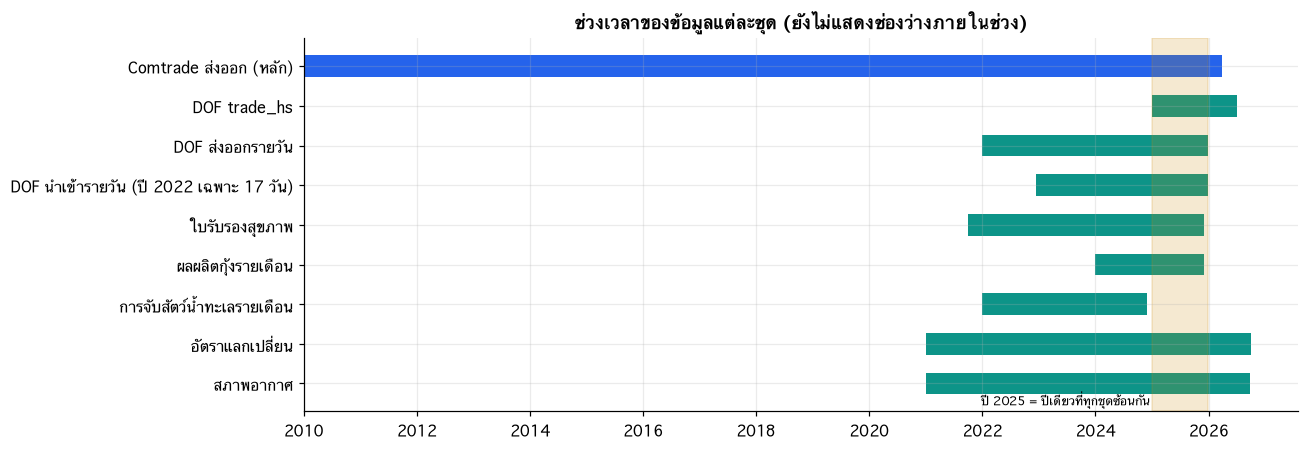

,เริ่ม,สิ้นสุด,ช่วง (เดือน),เดือนที่มีข้อมูลจริง
Comtrade ส่งออก (หลัก),2010-01,2026-04,196,196
DOF trade_hs,2025-01,2026-07,19,19
DOF ส่งออกรายวัน,2022-01,2025-12,48,48
DOF นำเข้ารายวัน (ปี 2022 เฉพาะ 17 วัน),2022-12,2025-12,37,37
ใบรับรองสุขภาพ,2021-10,2025-12,51,36
ผลผลิตกุ้งรายเดือน,2024-01,2025-12,24,23
การจับสัตว์น้ำทะเลรายเดือน,2022-01,2024-12,36,36
อัตราแลกเปลี่ยน,2020-12,2026-09,70,70
สภาพอากาศ,2021-01,2026-09,69,69


In [33]:
rng_series = {
    "Comtrade ส่งออก (หลัก)": cm.date, "DOF trade_hs": th.date, "DOF ส่งออกรายวัน": dx.date,
    "DOF นำเข้ารายวัน (ปี 2022 เฉพาะ 17 วัน)": di.date, "ใบรับรองสุขภาพ": hc.date, "ผลผลิตกุ้งรายเดือน": sh.date,
    "การจับสัตว์น้ำทะเลรายเดือน": mc.date, "อัตราแลกเปลี่ยน": fx.date, "สภาพอากาศ": wx.date,
}
rng = {k: (v.min(), v.max()) for k, v in rng_series.items()}
months_present = {k: v.dt.to_period("M").nunique() for k, v in rng_series.items()}
fig, ax = plt.subplots(figsize=(12, 4.2))
for i, (k, (s, e)) in enumerate(rng.items()):
    ax.barh(i, e - s, left=s, height=.55, color=C["blue"] if "หลัก" in k else C["teal"])
ax.set_yticks(range(len(rng))); ax.set_yticklabels(list(rng)); ax.invert_yaxis()
ax.axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"), color=C["gold"], alpha=.18); ax.text(pd.Timestamp("2024-12-20"), len(rng) - .45, "ปี 2025 = ปีเดียวที่ทุกชุดซ้อนกัน", fontsize=8, ha="right")
ax.set(title="ช่วงเวลาของข้อมูลแต่ละชุด (ยังไม่แสดงช่องว่างภายในช่วง)")
plt.tight_layout(); plt.show()
display(pd.DataFrame({k: {"เริ่ม": f"{s:%Y-%m}", "สิ้นสุด": f"{e:%Y-%m}", "ช่วง (เดือน)": (e.year - s.year) * 12 + e.month - s.month + 1, "เดือนที่มีข้อมูลจริง": months_present[k]} for k, (s, e) in rng.items()}).T)

## 2.11 สรุปปัญหาคุณภาพข้อมูลที่พบ

In [34]:
q = pd.DataFrame([
    ("DOF trade_hs", "แถวซ้ำทั้งแถว", int(issues.iloc[0]), "ลบ"),
    ("DOF trade_hs", "key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำแต่ค่าต่างกัน", int(issues.iloc[1]), "รวมยอดเป็น panel"),
    ("DOF trade_hs", "รหัสประเทศ 'yy' / รายละเอียดสินค้า '(blank)'", f"{int(issues.iloc[2])} / {int(issues.iloc[3]):,}", "ตั้งเป็นค่าว่าง + flag"),
    ("DOF รายวัน", "สำเนาแถวซ้ำส่วนเกิน (ส่งออก / นำเข้า)", f"{clog['export_daily_exact_dup_rows']:,} / {clog['import_daily_exact_dup_rows']:,}", "ต้องตัดสินใจ (เก็บ/ลบ)"),
    ("DOF รายวัน", "มูลค่าว่าง / ติดลบ (นำเข้า)", f"{int(dd.value_thb.isna().sum())} / {int((di.value_thb < 0).sum())}", "ตรวจและตัดสินใจ"),
    ("DOF รายวัน", "นำเข้าปี 2022 มีเพียง 17 วัน", 17, "ไม่ใช้ปี 2022 ฝั่งนำเข้า"),
    ("ใบรับรองสุขภาพ", "เดือนที่ไม่มีข้อมูลเลย", len(missing), "จำกัดการใช้ / เติมไม่ได้"),
    ("ใบรับรองสุขภาพ", "(ประเทศ, เดือน) ซ้ำ", len(dup), "รวมยอด"),
    ("ผลผลิตกุ้งรายเดือน", "ไฟล์ปี 2569 น่าจะเป็นปี 2568 (อนุมาน)", int(sh.year_inferred.sum()), "ยืนยันกับแหล่งข้อมูล"),
    ("Comtrade", f"HS 0308 ไม่มีรายการ {int(cover['0308'].isna().sum())} เดือน ({cover['0308'][cover['0308'].isna()].index.min():%Y-%m} ถึง {cover['0308'][cover['0308'].isna()].index.max():%Y-%m})", int(cover["0308"].isna().sum()), "ตีความเป็นไม่มีการค้า (ยืนยันก่อน)"),
    ("Comtrade", "แถวคู่ค้าที่ไม่มีรหัสประเทศ ISO2 (กลุ่ม 'nes' ฯลฯ) % มูลค่าปี 2025", f"{nes_share:.1%}", "แยกเป็นกลุ่ม 'ไม่ระบุ' ไม่นำไป join"),
    ("Comtrade", "คอลัมน์ qty_unit ว่างทั้งหมด / cif_usd ว่างครึ่งหนึ่ง", "100% / 49.7%", "ไม่ใช้ 2 คอลัมน์นี้"),
    ("World Bank", "ประเทศที่ไม่มี GDP ปี 2025 (จาก 217)", int(217 - wb[wb.year == 2025].gdp_usd.notna().sum()), "ใช้ปีล่าสุดที่มี"),
    ("ราคา", "ไม่มีตัวเลขราคา มีแต่ metadata", 0, "ตัดออกจากโจทย์"),
], columns=["ชุดข้อมูล", "ปัญหา", "จำนวน", "แนวทางที่วางไว้"])
display(q)

,ชุดข้อมูล,ปัญหา,จำนวน,แนวทางที่วางไว้
0,DOF trade_hs,แถวซ้ำทั้งแถว,12,ลบ
1,DOF trade_hs,"key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำแต่ค่าต่างกัน",15659,รวมยอดเป็น panel
2,DOF trade_hs,รหัสประเทศ 'yy' / รายละเอียดสินค้า '(blank)',"38 / 13,710",ตั้งเป็นค่าว่าง + flag
3,DOF รายวัน,สำเนาแถวซ้ำส่วนเกิน (ส่งออก / นำเข้า),"59,393 / 20,061",ต้องตัดสินใจ (เก็บ/ลบ)
4,DOF รายวัน,มูลค่าว่าง / ติดลบ (นำเข้า),90 / 14,ตรวจและตัดสินใจ
5,DOF รายวัน,นำเข้าปี 2022 มีเพียง 17 วัน,17,ไม่ใช้ปี 2022 ฝั่งนำเข้า
6,ใบรับรองสุขภาพ,เดือนที่ไม่มีข้อมูลเลย,15,จำกัดการใช้ / เติมไม่ได้
7,ใบรับรองสุขภาพ,"(ประเทศ, เดือน) ซ้ำ",2,รวมยอด
8,ผลผลิตกุ้งรายเดือน,ไฟล์ปี 2569 น่าจะเป็นปี 2568 (อนุมาน),826,ยืนยันกับแหล่งข้อมูล
9,Comtrade,HS 0308 ไม่มีรายการ 24 เดือน (2010-01 ถึง 2011-12),24,ตีความเป็นไม่มีการค้า (ยืนยันก่อน)


### 📝 อ่านผล: ปัญหาคุณภาพข้อมูลที่ต้องจัดการใน Data Preparation

- ปัญหาที่ **กระทบการวิเคราะห์โดยตรง:** (1) key ซ้ำใน `trade_hs` 15,659 แถว (2) สำเนาซ้ำรายวัน 59,393 / 20,061 แถว ซึ่งยังตัดสินไม่ได้ว่าลบหรือเก็บ (3) ใบรับรองสุขภาพขาด 15 เดือน (4) ข้อมูลกุ้งไฟล์ "2569" ต้องยืนยันปี
- ปัญหา **เล็ก/จัดการได้ง่าย:** รหัสประเทศ "yy", ค่า "(blank)", มูลค่าว่าง 90 แถว, มูลค่าติดลบ 14 แถว (นำเข้า), HS 0308 ที่ไม่มีรายการ 24 เดือนแรก (ปี 2010–2011)
- **Comtrade (ข้อมูลหลัก) สะอาดที่สุด:** ผลรวมรายประเทศตรงกับยอดรวม (ผลต่างสัมพัทธ์สูงสุด 2.9×10⁻⁹) ครบ 196 เดือน และตรงกับข้อมูลกรมประมงปี 2025 ภายใน ±3% ต่อเดือน

---
### 2.12 สรุป Data Understanding: ข้อมูลพอสำหรับโจทย์ไหน

| โจทย์ | ข้อมูลที่ใช้ | ความพอเพียง | หลักฐานจากข้อมูลในส่วนที่ 2 |
|---|---|---|---|
| **Goal 1 (หลัก). พยากรณ์ยอดรายเดือน (ประเทศ × HS)** | Comtrade | ✅ **ทำได้ และข้อมูลพอเชิงปริมาณ** (340 อนุกรม × 183 เดือน) · ⚠️ *คาดว่า ML จะไม่ชนะ baseline* — ตั้งไว้เป็นสมมติฐานที่ทดสอบ รายงานตามจริง | ไม่มีฤดูกาลในระดับอนุกรมย่อย (autocorr lag 12 = 0.05), กฎค่าเฉลี่ย 3–12 เดือนดีสุด (WAPE 0.220), seasonal naive แย่สุด (0.288) ⇒ เพดานความแม่นยำใกล้ 0.22 ความผันผวนลดลงเมื่อรวมยอด (0.72 รายเดือน → 0.47 รวม 3 เดือน → 0.28 รวม 12 เดือน) จึงควรทดสอบหลายระยะ/หลายระดับ |
| **Goal 2 (ต้องส่งมอบ). จัดกลุ่มตลาด (Clustering)** | Comtrade + World Bank | ✅ **พอ** | 1,148 อนุกรม 174 ประเทศ (2025) ข้อมูลน้ำหนักครบ 99.8% (คำนวณราคาต่อกก.ได้) World Bank join ได้ครบทุกประเทศที่มี ISO2 และไม่ต้องอาศัยพลังพยากรณ์ ใช้แบ่งกลุ่มเพื่ออธิบายความแม่นของ Goal 1 |
| **Goal 3 (เสริม). เตือนตลาดยอดตก (Classification)** | Comtrade | ✅ **พอให้ทดลอง** (ผลยังไม่รู้) | 340 อนุกรมที่เสถียร ≈ 55,000 จุดอนุกรม×เดือน คลาสบวก 26.9% (ไม่เอียงมาก) ความผันผวนของยอด 12 เดือนเหลือ 0.28 ⚠️ โอกาสตกต่อเนื่อง 54% ต้องชนะให้ได้ ⚠️ สัดส่วนการตกต่างกันมากตามปี (19%–39%) → ต้องทดสอบข้ามหลายช่วงเวลา |
| พยากรณ์ผลผลิตกุ้ง | กุ้งรายเดือน + อากาศ | ❌ **ไม่พอ** | มีเพียง 23 เดือน (ฤดูกาลชัด แต่ไม่พอเทรน/ทดสอบข้ามปี) |
| ใช้ใบรับรองสุขภาพเป็นตัวชี้นำ | ใบรับรอง | ❌ **ไม่มีหลักฐานว่าใช้ได้** | ภายในประเทศเดียวกัน corr = 0.02 / −0.14, ขาด 15 เดือน |
| ใช้ราคาตลาด | ราคาสะพานปลา | ❌ **ไม่มีข้อมูล** | มีแต่ metadata |

**สิ่งที่ยืนยันแล้วเกี่ยวกับความน่าเชื่อถือ:** ข้อมูลหลัก (Comtrade) ตรงกับข้อมูลกรมประมงภายใน ±3% ต่อเดือนเมื่อเทียบ HS ชุดเดียวกัน

**ข้อที่ต้องตัดสินใจใน Data Preparation (สำหรับ Goal 1: ระยะพยากรณ์ 1/3/6 เดือน, ระดับการรวม, ช่วงทดสอบ 36 เดือนล่าสุด)**
1. **ช่วงข้อมูลเทรน:** ใช้ปี 2015 เป็นต้นไปเพื่อเลี่ยงการเปลี่ยนโครงสร้างช่วง 2011–2015 (ยืนยันกับอาจารย์/ทีม)
2. **นิยามป้ายกำกับของ Goal 3 (ถ้าทำ):** ตกเกิน 20% ภายใน 6 เดือน ปรับได้ — ควรทดลอง 10/20/30% และ 3/6/12 เดือน
3. **เกณฑ์อนุกรมที่ใช้ได้:** เสนอ ≥ 36 เดือนจาก 60 เดือนล่าสุด (340 อนุกรม, 98.8% ของมูลค่า)
4. **ตัวแปร:** วิเคราะห์เป็น USD ปรับสเกลแยกตามกลุ่ม HS (เพราะ 1604 = 59%)
5. **แถวซ้ำรายวัน:** เก็บหรือลบ (ข้อมูลรายวันเป็นข้อมูลเสริม ไม่กระทบโจทย์หลัก)
6. **ยืนยันกับแหล่งข้อมูล:** ปีของไฟล์กุ้ง "2569" และหน่วยของคอลัมน์ที่ยังเป็น "อนุมาน"

> **สถานะ:** Business Understanding และ Data Understanding เสร็จแล้ว ส่วน Data Preparation, Modeling, Evaluation, Deployment ยังไม่ได้เริ่ม